In [14]:
import json
from numpy import median
import pandas as pd
from datetime import timedelta
import numpy as np

def safe_median(values, warn=True):
    '''
    To avoid issues with None or NaN values when computing the median.
    '''
    values = list(values)
    clean = [v for v in values if v is not None and not pd.isna(v)]

    if warn and len(clean) < len(values):
        print(f"{len(values) - len(clean)} ignored values when computing the median.")

    return median(clean) if clean else np.nan
    
def load_jsonl_cleaned(input_file, max_lines = -1, print_progress=True):
    '''
    Load a JSONL file and convert it into a pandas DataFrame.

    :param input_file: path of the JSONL file to load
    :return: pandas DataFrame
    '''
    rows = []
    cpt = 0 # To satisfy the max_lines constraints
    for file in input_file:
        if cpt == max_lines:
            break
        with open(file, 'r', encoding='utf-8') as f:
            total_lines = sum(1 for _ in f) * len(input_file)
            f.seek(0) # Reset file pointer to the beginning after counting lines
            for line in f:
                if cpt == max_lines:
                    break
                cpt += 1
                line = line.strip()
    
                if print_progress and cpt % 100 == 0:
                    print(f"\rTraitement ligne {cpt}/{total_lines}", end="", flush=True)
                if line:
                    item = json.loads(line) ## Load the JSON content
                    content = next(iter(item.values())) ## Get the first value of the dictionary
                    
                    if 'qubits' in content:
                        ## Clean the content and taking the median of all the relevant values in qubits
                        content['t1'] = safe_median(list(map(lambda x: x['t1'], content['qubits'].values())))
                        content['t2'] = safe_median(list(map(lambda x: x['t2'], content['qubits'].values())))
                        content['readout_error'] = safe_median(list(map(lambda x: x['readout_error'], content['qubits'].values())))
                        content['prob_meas0_prep1'] = safe_median(list(map(lambda x: x['prob_meas0_prep1'], content['qubits'].values())))
                        content['prob_meas1_prep0'] = safe_median(list(map(lambda x: x['prob_meas1_prep0'], content['qubits'].values())))
                        content.pop('qubits', None)
        
                    if 'gates' in content:
                    ## Clean and taking cols according to the EDA 
                    ### Take the id gates as a referential for single gates metrics
                        if 'id' not in content.get('gates', {}):
                            content['single_gates'] = np.nan
                        else:   
                            content['single_gates'] = safe_median(list(map(lambda x: x['error'], content['gates']['id'].values())))
                        
                        if 'cz' not in content.get('gates', {}):
                            content['cz_error'] = np.nan
                        else:
                            content['cz_error'] = safe_median(list(map(lambda x: x['error'], content['gates']['cz'].values())))
                            
                        if 'rzz' not in content.get('gates', {}):
                            content['rzz_error'] = np.nan
                        else:
                            content['rzz_error'] = safe_median(list(map(lambda x: x['error'], content['gates']['rzz'].values())))
        
                        content.pop('gates', None)
                    
                    rows.append(content)

    df = pd.DataFrame(rows)
    df['calibration_time'] = pd.to_datetime(df['calibration_time'], format='%Y-%m-%d_%H:%M:%S')
    df = df.drop_duplicates(subset=['calibration_time', 'backend'])

    ## Sort each backend by calibration time and backend name
    df_torino = df[df['backend'] == 'ibm_torino'].copy()
    df_torino = df_torino.sort_values('calibration_time').reset_index(drop=True)
    df_torino.ffill(inplace=True)
    
    df_fez = df[df['backend'] == 'ibm_fez'].copy()
    df_fez = df_fez.sort_values('calibration_time').reset_index(drop=True)
    df_fez.ffill(inplace=True)
    
    df_marrakesh = df[df['backend'] == 'ibm_marrakesh'].copy()
    df_marrakesh = df_marrakesh.sort_values('calibration_time').reset_index(drop=True)
    df_marrakesh.ffill(inplace=True)
    
    return df, df_torino, df_fez, df_marrakesh

In [18]:
import os 
from pathlib import Path
'''
Load the dataset and clean it by taking the median of the relevant values in qubits and gates, and then drop the qubits and gates columns.  
We also sort each backend by calibration time and backend name.
This function take a list of files as input so you can either :
- Load a single file by passing a list with one element (ex: [files[1]])
- Load all the files by passing the list of all the files (ex: files)
'''
dataset_folder = Path("../dataset")
files = []
for dirname, _, filenames in os.walk(dataset_folder):
    for filename in filenames:
        files.append(f"{dirname}/{filename}")

files = [f for f in files if "weekly_merge" not in str(f)] ## To avoid loading the already merged files in the dataset
''' 
- Other way to extract : by taking the weekly files (and complete here)
weekly_files = [f for f in files if ("weekly_merge" in str(f) and "complete" in str(f))]
''' 

file = [files[0]] ## Load the first file of the dataset (complete dataset)

df, df_torino, df_fez, df_marrakesh = load_jsonl_cleaned(file, print_progress=False)

# Models

## Gru / LSTM / Linear Regression

In [5]:
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_prob):
        """Args:
            input_dim (int): The number of nodes in the input layer
            hidden_dim (int): The number of nodes in each layer
            layer_dim (int): The number of layers in the network
            output_dim (int): The number of nodes in the output layer
            dropout_prob (float): The probability of nodes being dropped out
        """
        super(GRUModel, self).__init__()
        
        self.layer_dim = layer_dim
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        """The forward method takes input tensor x and does forward propagation

        Args:
            x (torch.Tensor): The input tensor of the shape (batch size, sequence length, input_dim)

        Returns:
            torch.Tensor: The output tensor of the shape (batch size, output_dim)

        """
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        out, _ = self.gru(x, h0.detach())
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)

        return out

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_prob):
        """Args:
            input_dim (int): The number of nodes in the input layer
            hidden_dim (int): The number of nodes in each layer
            layer_dim (int): The number of layers in the network
            output_dim (int): The number of nodes in the output layer
            dropout_prob (float): The probability of nodes being dropped out
        """
        super(LSTMModel, self).__init__()
        
        self.layer_dim = layer_dim
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """The forward method takes input tensor x and does forward propagation

        Args:
            x (torch.Tensor): The input tensor of the shape (batch size, sequence length, input_dim)

        Returns:
            torch.Tensor: The output tensor of the shape (batch size, output_dim)

        """
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim,device=x.device).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = out[:, -1, :]
        out = self.fc(out)

        return out

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

## Optimization

In [ ]:
from torch import device
import torch
## Made on Kaggle, so we use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Optimisation:
    '''
    Optimisation class, taking several object to automatize the training
    Input:
        - model: model we use to train
        - loss_fn: loss function (usually MSE)
        - optimizer: optimizer (almost everytime Adam)
    '''
    def __init__(self, model, loss_fn, optimizer):
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.train_losses = []
        self.val_losses = []

    def train_step(self, x, y):
        '''
        Compute the gradient stept by step
        '''
        self.model.train()
        y_pred = self.model(x)
        loss = self.loss_fn(y_pred, y)
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad() ## reset the grad
        return loss.item()
    
    def train(self, train_loader, val_loader, batch_size=32, n_epochs=5, n_features = None, show_print=True):
        '''
        Full training loop
        '''
        best_val_loss = float("inf")
        patience = 10
        counter = 0
        model.to(device)

        for epoch in range(1, n_epochs+1):
            batch_losses = []
            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                loss = self.train_step(x_batch, y_batch) 
                batch_losses.append(loss) 
            train_loss = np.mean(batch_losses)
            self.train_losses.append(train_loss)
            if show_print:
                print(f'Epoch {epoch}/{n_epochs}, Loss: {train_loss:.4f}')

            with torch.no_grad():
                batch_val_losses = []
                self.model.eval()
                for x_val_batch, y_val_batch in val_loader:
                    x_val_batch = x_val_batch.to(device)
                    y_val_batch = y_val_batch.to(device)
                    ypred = self.model(x_val_batch)
                    val_loss = self.loss_fn(ypred, y_val_batch)
                    batch_val_losses.append(val_loss.item())
                val_loss = np.mean(batch_val_losses)
                self.val_losses.append(val_loss)

            if show_print:
                if (epoch <= 10) | (epoch % 50 == 0):
                        print(
                            f"[{epoch}/{n_epochs}] Training loss: {train_loss:.4f}\t Validation loss: {val_loss:.4f}"
                        )
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"Early stopping at epoch {epoch}, train_loss = {train_loss:.4f}\t Validation loss: {val_loss:.4f}")
                    break

## Dataset

In [7]:
from torch.utils.data import Dataset
import torch
from sklearn.preprocessing import StandardScaler

class TimeSeriesDataset(Dataset):
    def __init__(self, data, steps, target_cols):
        """
        data: whole dataframe (n_samples, n_features)
        steps: number of steps we want to use to predict the futrue
        target_cols: columns we want to predict (often one)
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.steps = steps
        self.target_cols = target_cols

    def __len__(self):
        return len(self.data) - self.steps

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.steps]
        y = self.data[idx+self.steps, self.target_cols]

        return x, y

def prepare_data(df):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df)
    return data_scaled, scaler

def split_data(data):
    train_size = int(0.8 * len(data))
    val_size = int(0.8 * train_size)

    train = data[:val_size]
    val = data[val_size:train_size]
    test = data[train_size:]

    return train, val, test

# Pre normalisation outliers detection

## Fez

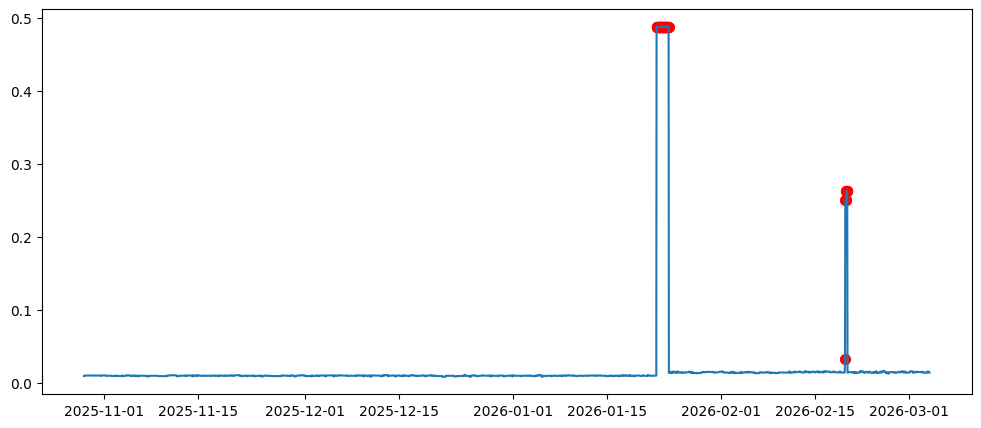

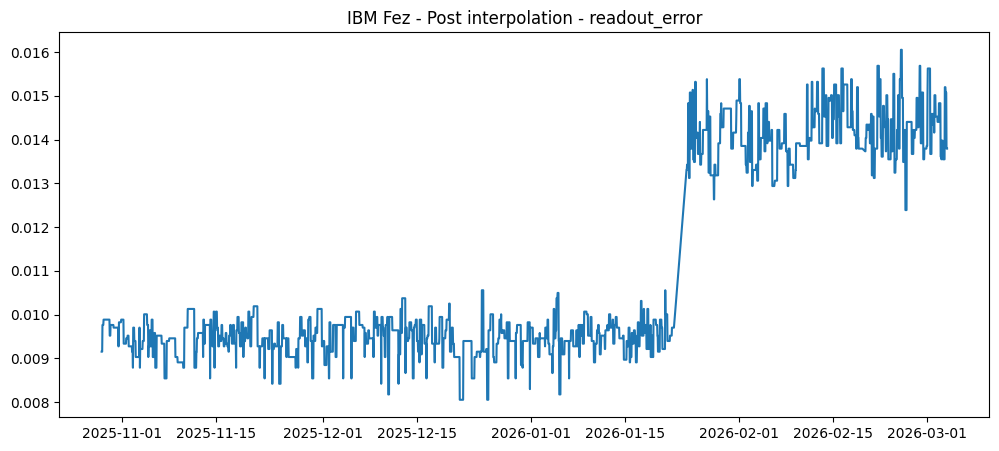

In [ ]:
import matplotlib.pyplot as plt

df_out = df_fez.copy()
metric = 'readout_error'

Q1 = df_out[metric].quantile(0.05)
Q3 = df_out[metric].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_fez['calibration_time'], df_fez[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_fez_{metric}.png')
plt.show()

df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Fez - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_fez_{metric}.png')
plt.show()

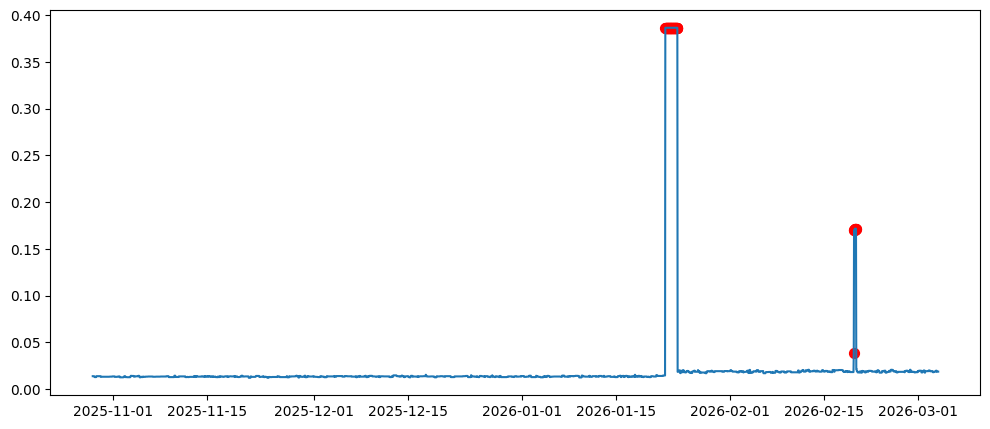

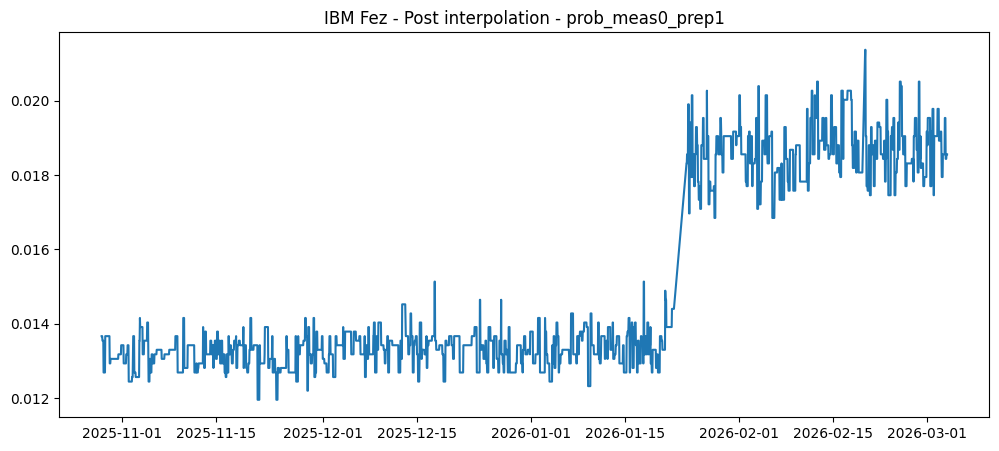

In [ ]:
metric = 'prob_meas0_prep1'

Q1 = df_out[metric].quantile(0.05)
Q3 = df_out[metric].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_fez['calibration_time'], df_fez[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_fez_{metric}.png')
plt.show()

df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Fez - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_fez_{metric}.png')
plt.show()

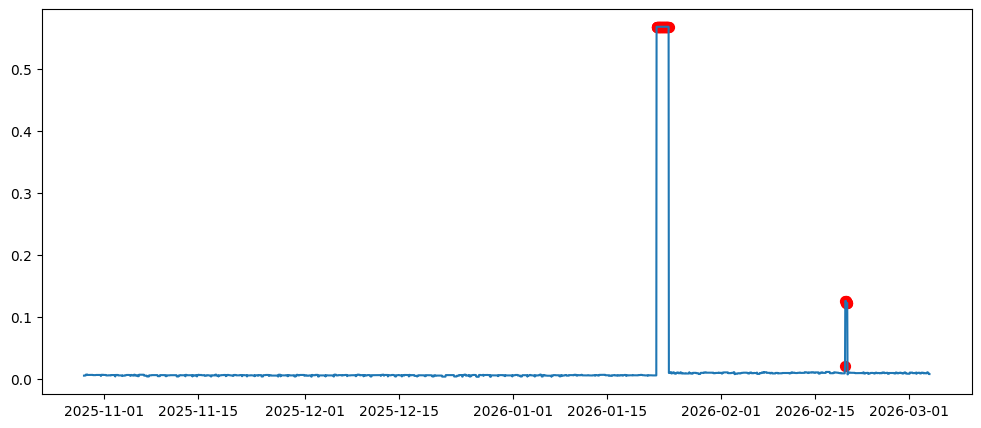

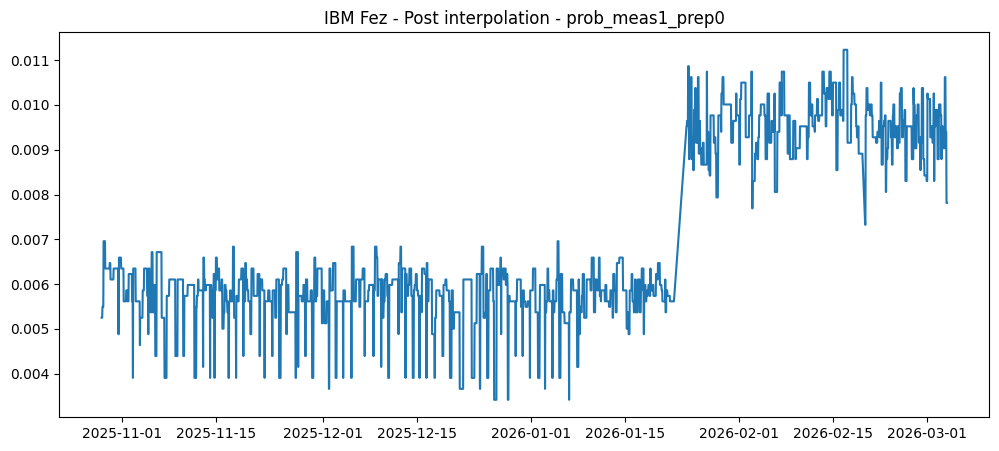

In [ ]:
metric = 'prob_meas1_prep0'

Q1 = df_out[metric].quantile(0.05)
Q3 = df_out[metric].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_fez['calibration_time'], df_fez[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_fez_{metric}.png')
plt.show()

df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Fez - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_fez_{metric}.png')
plt.show()

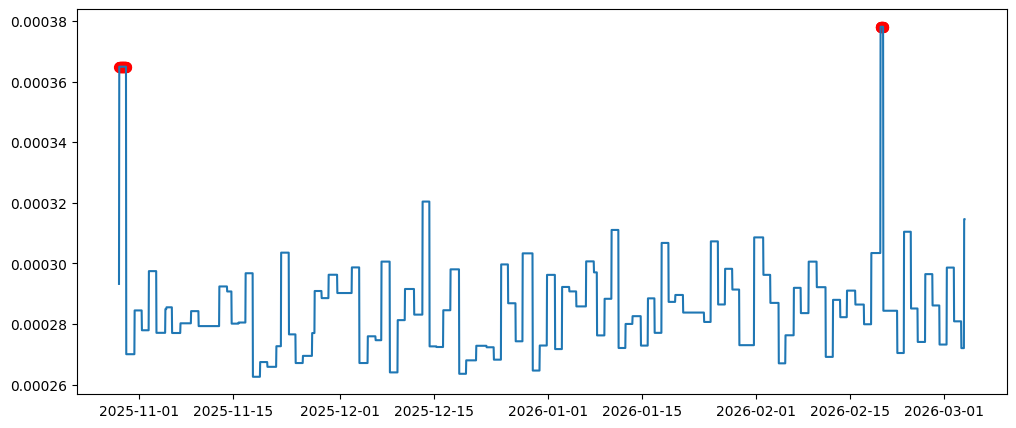

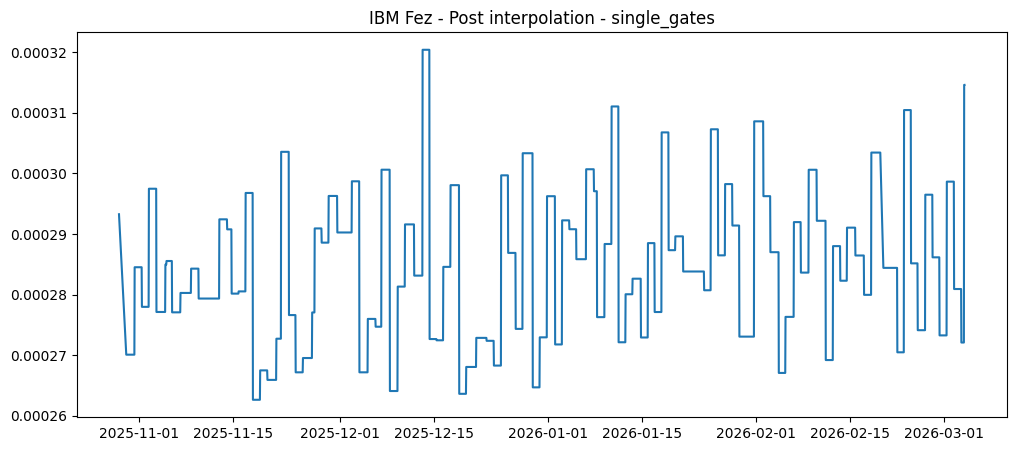

In [ ]:
metric = 'single_gates'

Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_fez['calibration_time'], df_fez[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_fez_{metric}.png')
plt.show()

df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Fez - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_fez_{metric}.png')
plt.show()

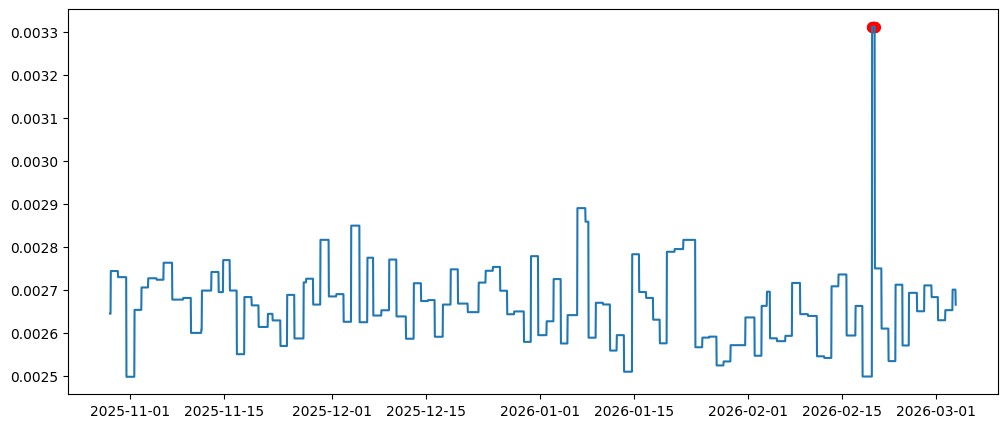

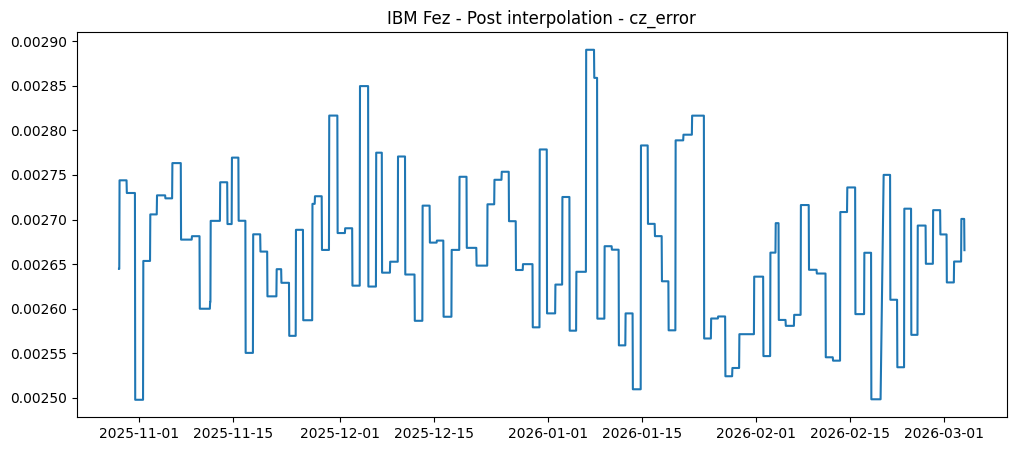

In [ ]:
metric = 'cz_error'

Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_fez['calibration_time'], df_fez[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_fez_{metric}.png')
plt.show()

df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Fez - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_fez_{metric}.png')
plt.show()

In [13]:
## replacing the old df_fez by the cleaned one
df_fez = df_out.copy()

## Torino

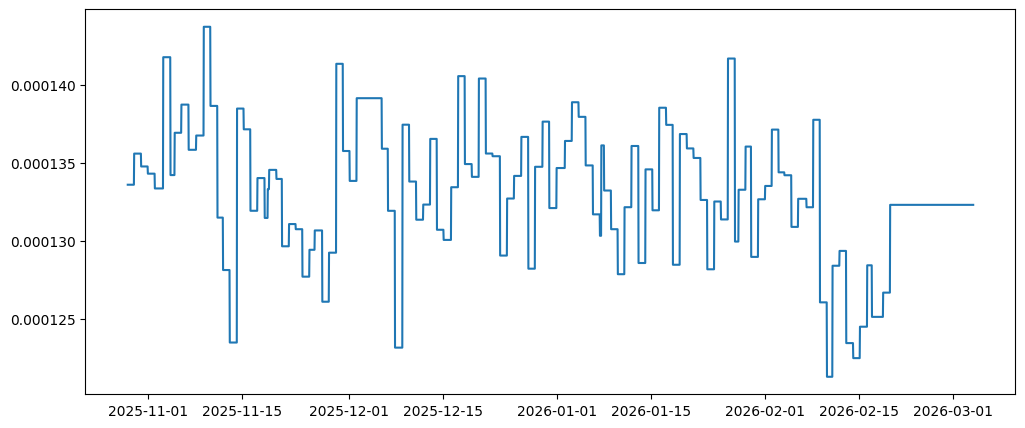

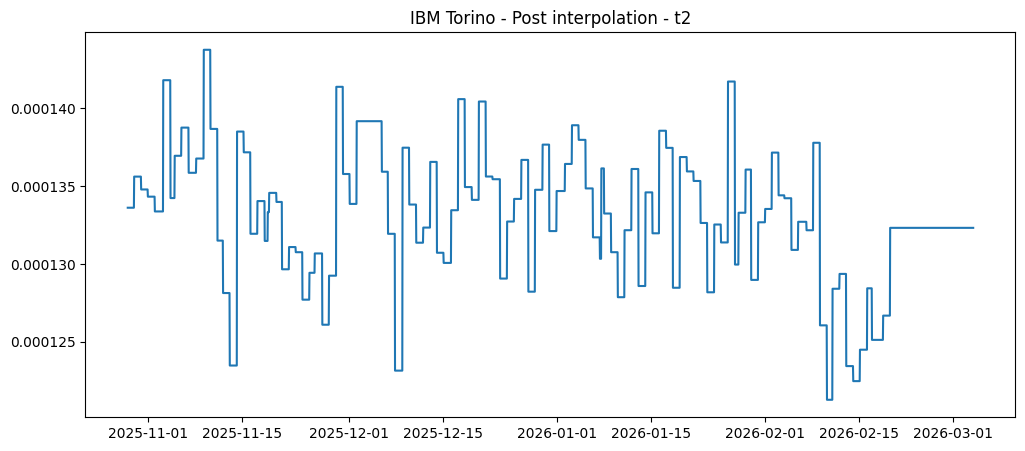

In [ ]:
df_out = df_torino.copy()
metric = 't2'

Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_torino['calibration_time'], df_torino[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_torino_{metric}.png')
plt.show()

## FEZ - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Torino - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_torino_{metric}.png')
plt.show()

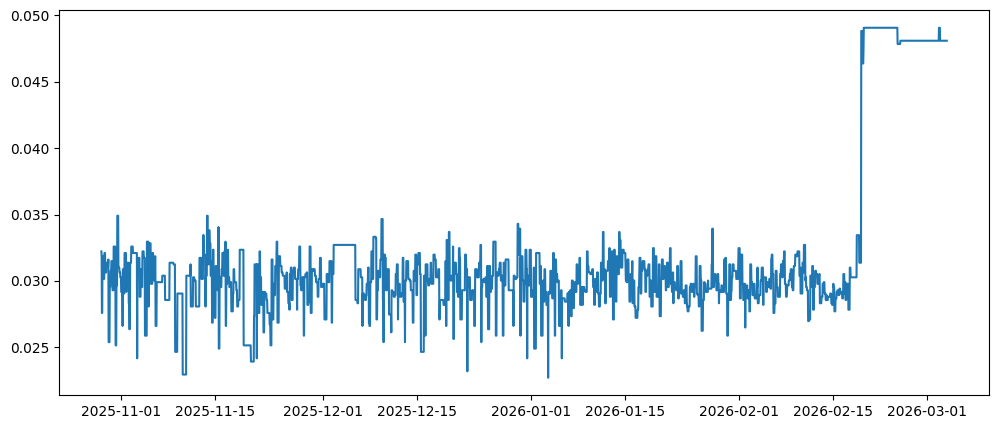

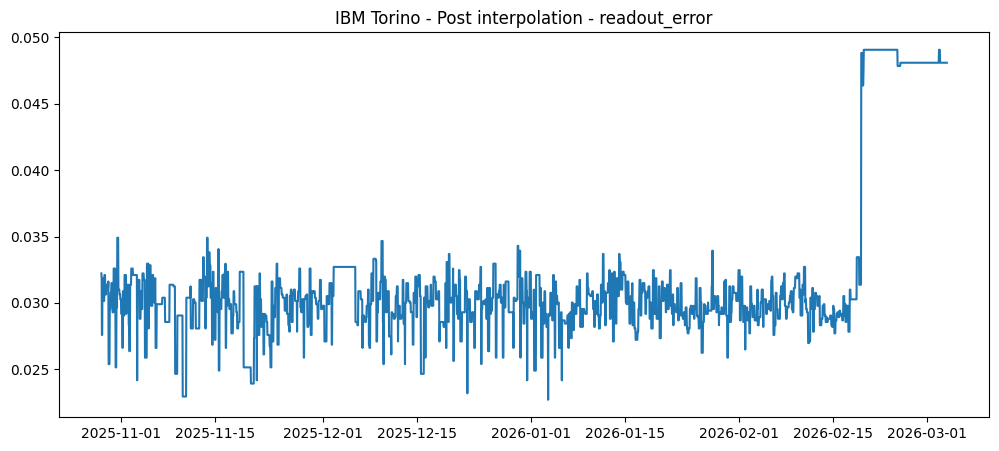

In [ ]:
metric = 'readout_error'

Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_torino['calibration_time'], df_torino[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_torino_{metric}.png')
plt.show()

## Torino - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Torino - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_torino_{metric}.png')
plt.show()

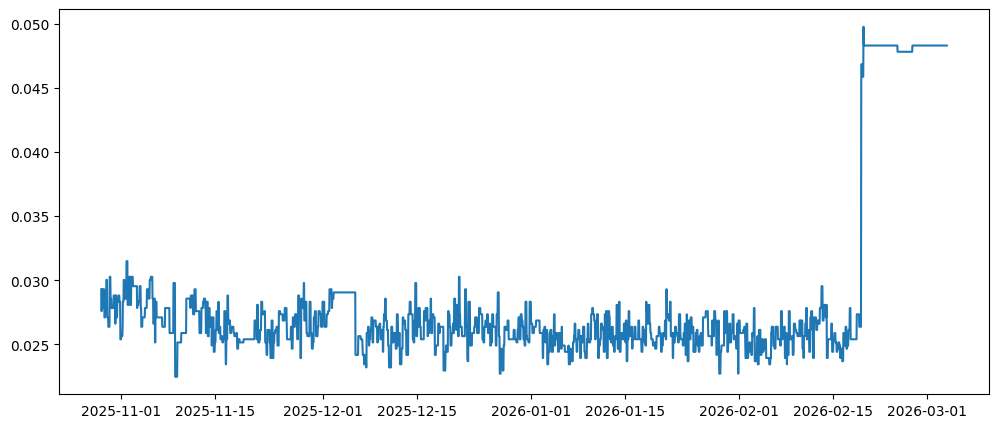

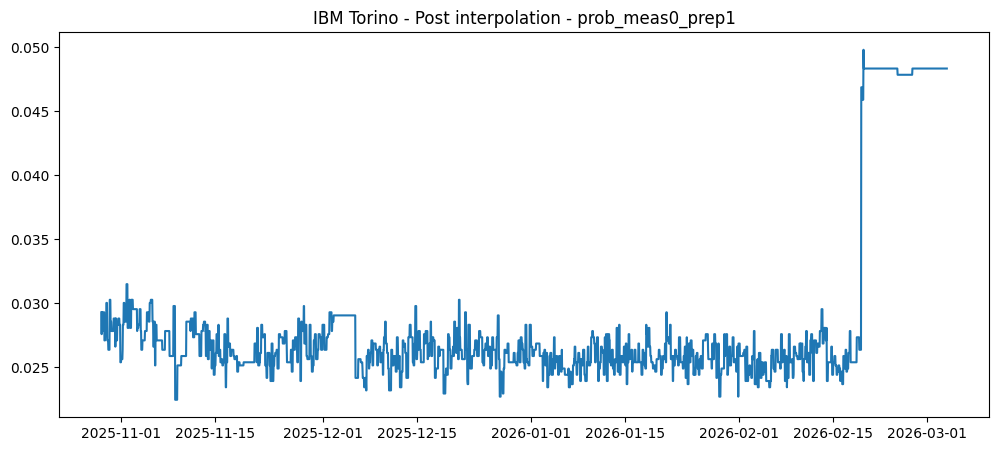

In [16]:
metric = 'prob_meas0_prep1'

Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_torino['calibration_time'], df_torino[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_torino_{metric}.png')
plt.show()

## Torino - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Torino - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_torino_{metric}.png')
plt.show()

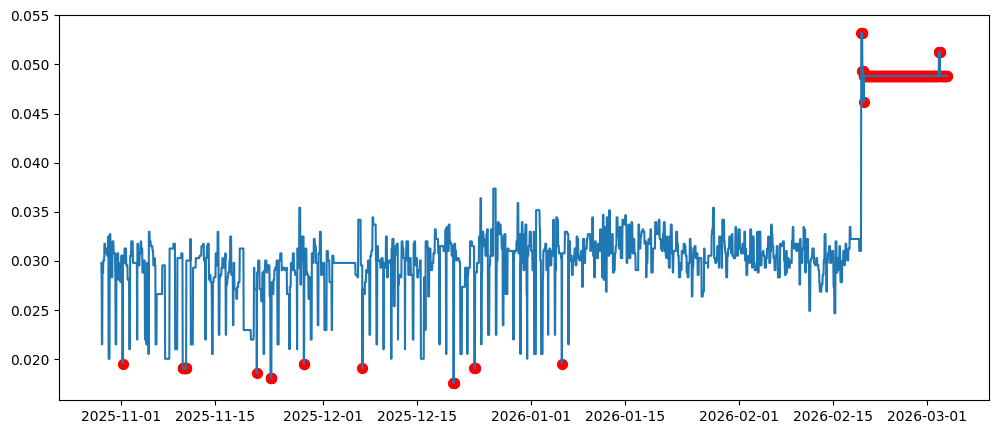

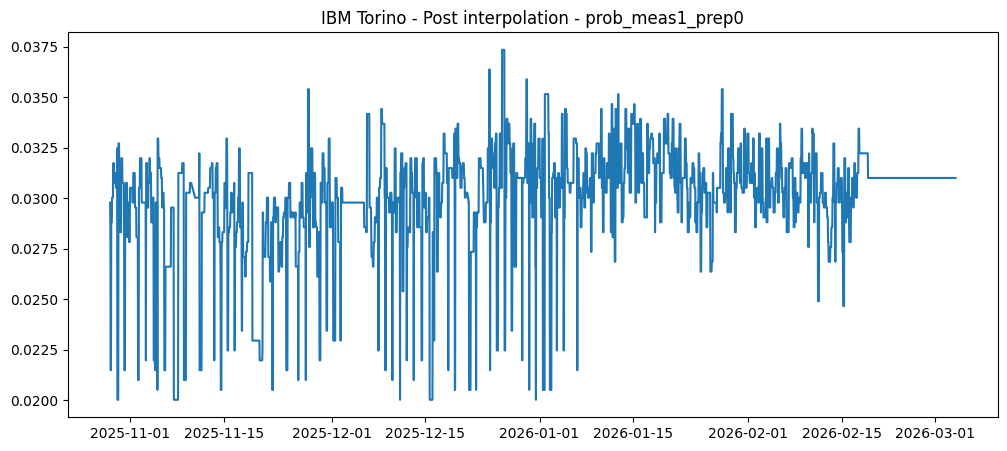

In [17]:
metric = 'prob_meas1_prep0'

Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_torino['calibration_time'], df_torino[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_df_torino_{metric}.png')
plt.show()

## Torino - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Torino - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_torino_{metric}.png')
plt.show()

In [18]:
## replacing the old df by the cleaned one
df_torino = df_out.copy()

## Marrakesh

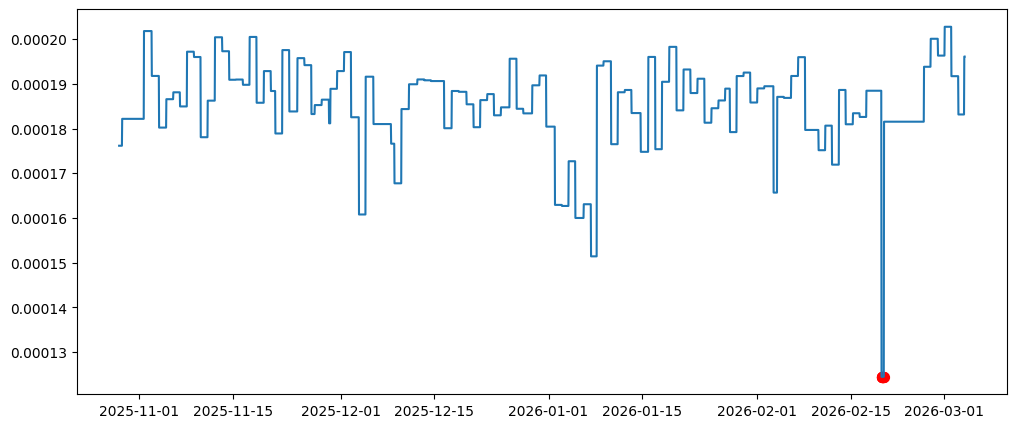

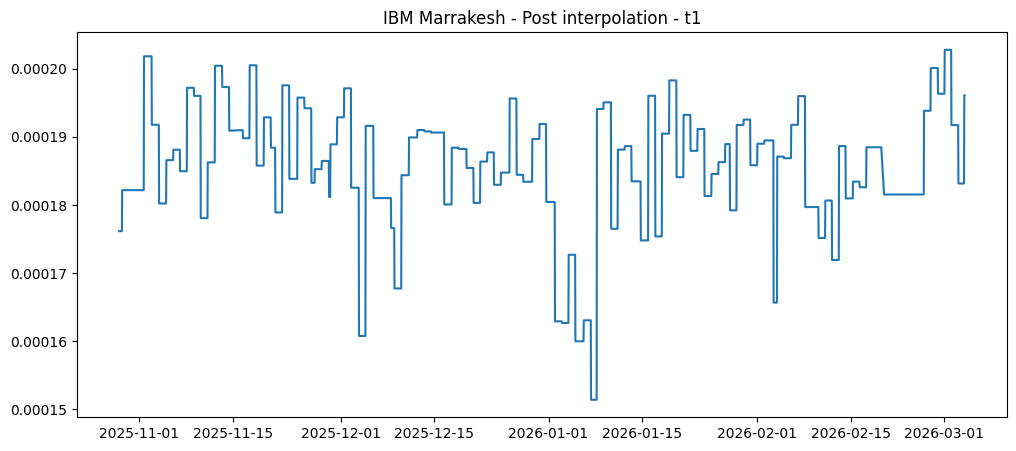

In [19]:
df_out = df_marrakesh.copy()
metric = 't1'

Q1 = df_out[metric].quantile(0.1)
Q3 = df_out[metric].quantile(0.9)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_marrakesh['calibration_time'], df_marrakesh[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_ibm_marrakesh_{metric}.png')
plt.show()

## Marrakesh - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Marrakesh - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_marrakesh_{metric}.png')
plt.show()

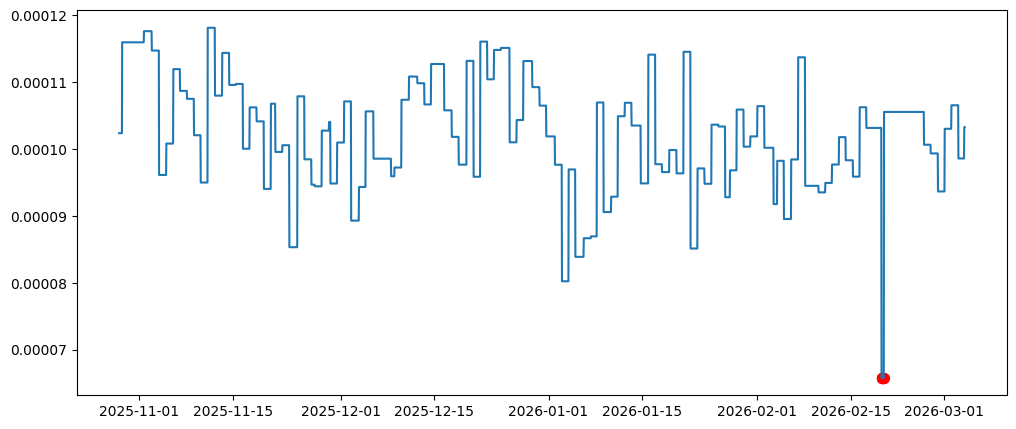

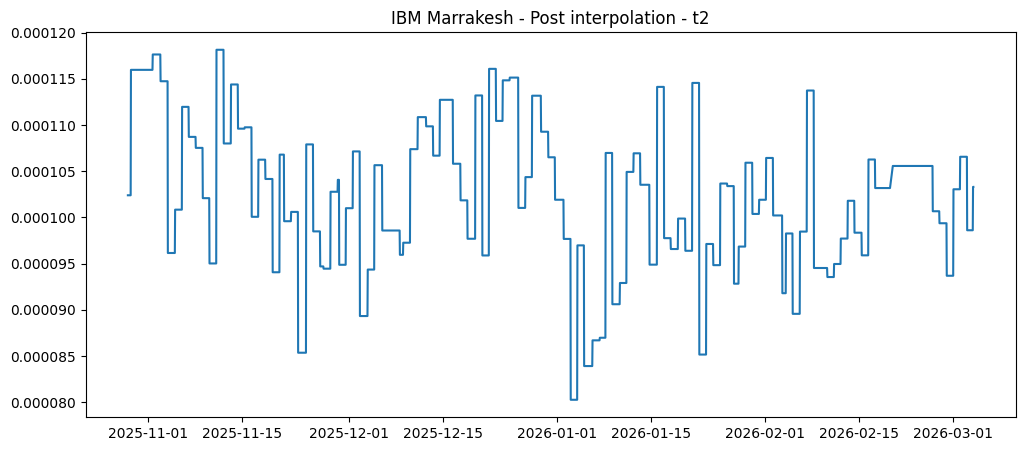

In [20]:
metric = 't2'

Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_marrakesh['calibration_time'], df_marrakesh[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_ibm_marrakesh_{metric}.png')
plt.show()

## Marrakesh - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Marrakesh - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_marrakesh_{metric}.png')
plt.show()

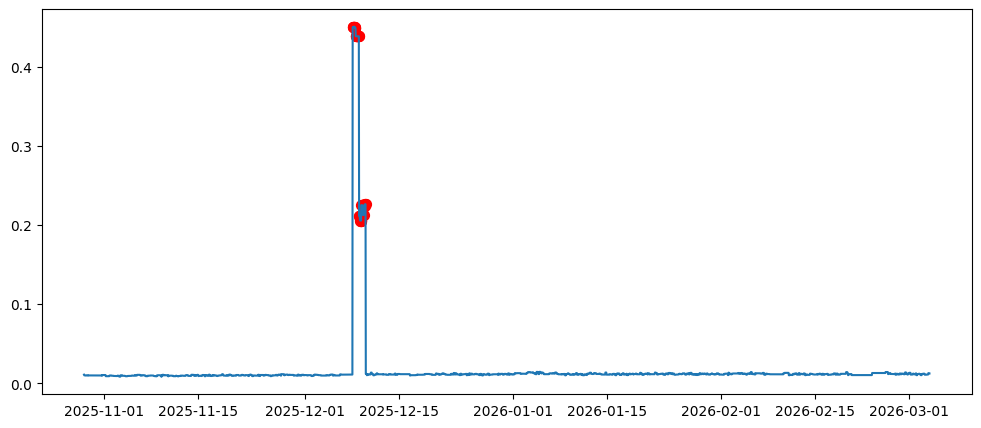

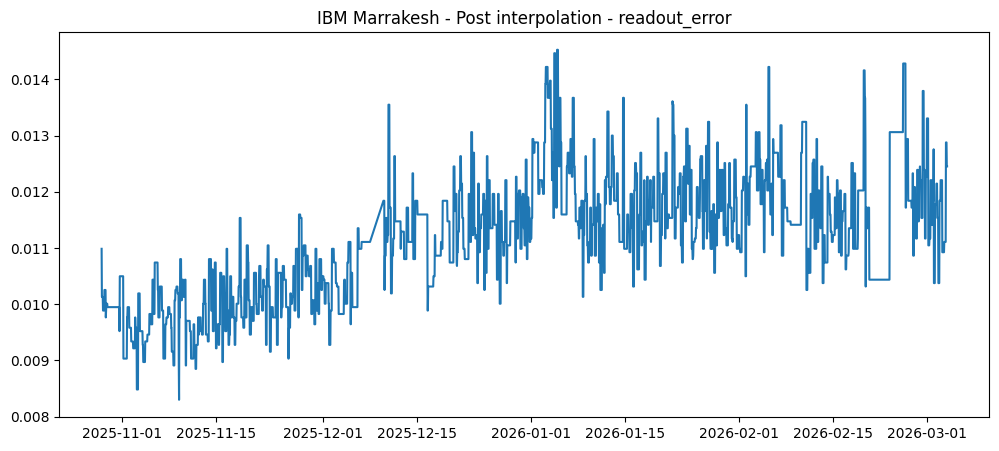

In [21]:
metric = 'readout_error'

Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_marrakesh['calibration_time'], df_marrakesh[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_ibm_marrakesh_{metric}.png')
plt.show()

## Marrakesh - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Marrakesh - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_marrakesh_{metric}.png')
plt.show()

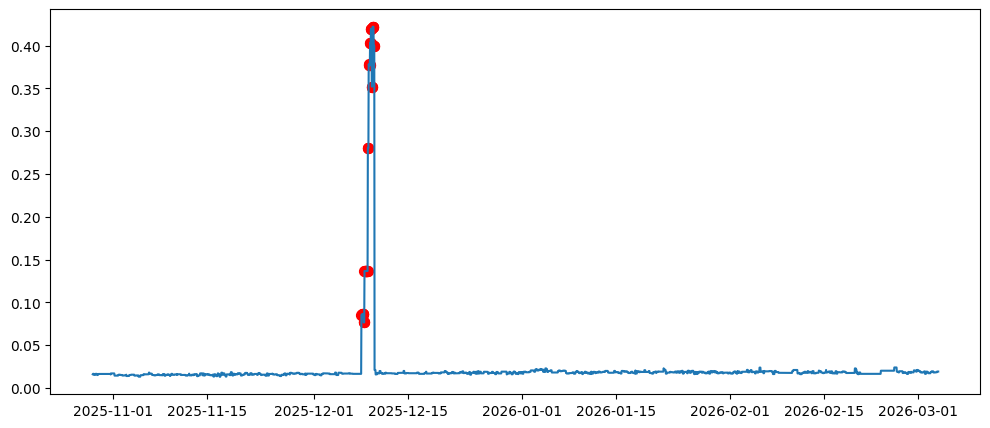

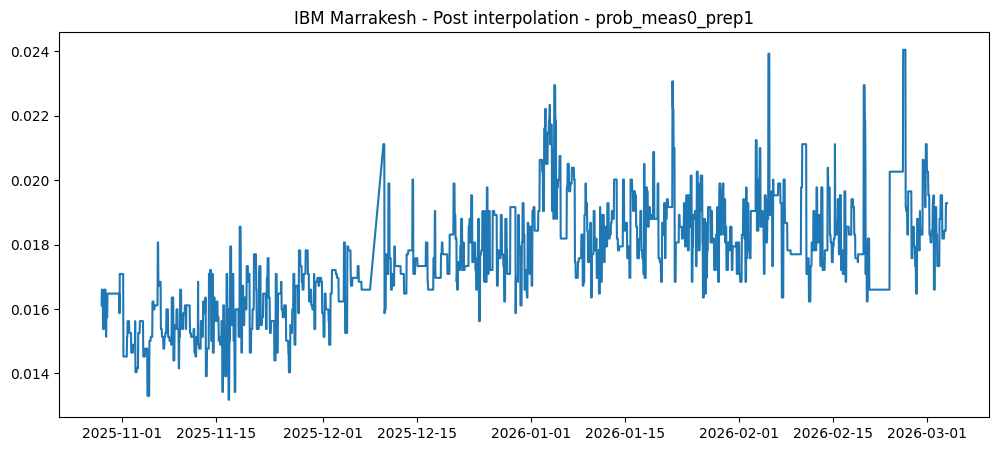

In [22]:
metric = 'prob_meas0_prep1'

Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_marrakesh['calibration_time'], df_marrakesh[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_ibm_marrakesh_{metric}.png')
plt.show()

## Marrakesh - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Marrakesh - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_marrakesh_{metric}.png')
plt.show()

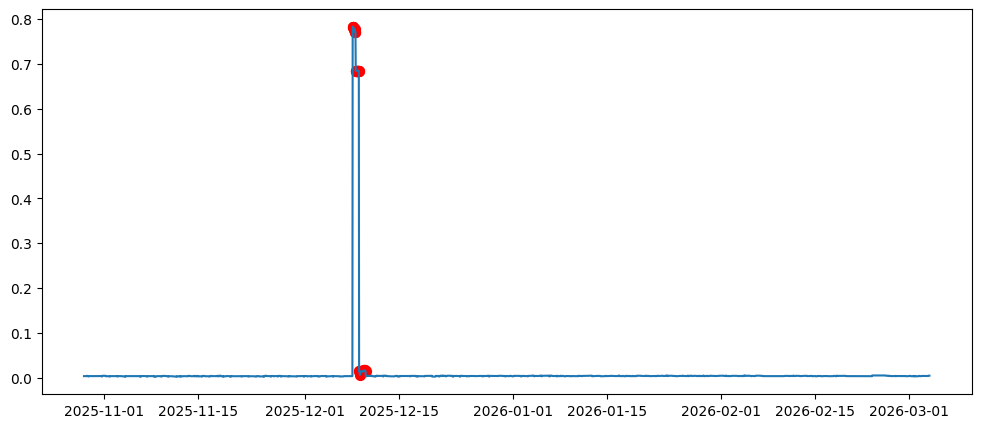

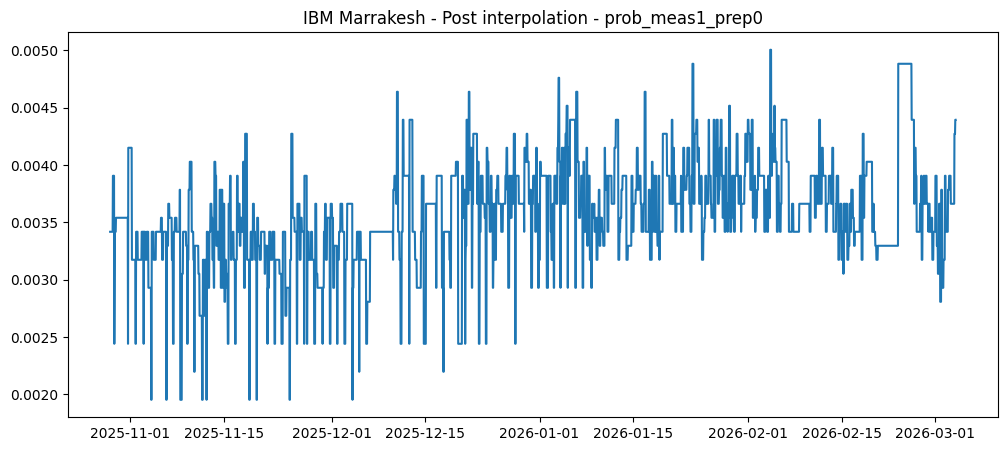

In [23]:
metric = 'prob_meas1_prep0'

Q1 = df_out[metric].quantile(0.15)
Q3 = df_out[metric].quantile(0.85)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask_outliers = (df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)
outliers_iqr = df_out[(df_out[metric] < lower_bound) | (df_out[metric] > upper_bound)]

plt.figure(figsize=(12,5))
plt.plot(df_marrakesh['calibration_time'], df_marrakesh[metric], linestyle='-', label='All points')
plt.scatter(outliers_iqr['calibration_time'], outliers_iqr[metric], color='red', label='Outliers', s=50)
plt.savefig(f'detected_outliers_ibm_marrakesh_{metric}.png')
plt.show()

## Marrakesh - READOUT ERROR CLEANING 
df_out.loc[mask_outliers, metric] = np.nan
df_out[metric] = df_out[metric].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df_out['calibration_time'], df_out[metric], linestyle='-', label='All points')
plt.title(f"IBM Marrakesh - Post interpolation - {metric}")
plt.savefig(f'post_interpolation_ibm_marrakesh_{metric}.png')
plt.show()

In [24]:
## replacing bythe cleaned one
df_marrakesh = df_out.copy()

# Starting the pipeline

In [25]:
# import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from random import randint
import  matplotlib.pyplot as plt

device = torch.device("cpu")

## Splitting my set in a train, val, test
def train_val_test_process_for_train(df, steps = 24):
    '''
    Take a one features dataframe to create a dataloader only with this features
    '''
    data = df
    X_train = []
    y_train = []
    
    X_val = []
    y_val = []
    
    X_test = []
    y_test = []
    
    train_test_split = int(0.8 * len(df))
    train_val_split = int(0.8 * train_test_split)
    
    train_raw = data[:train_val_split]
    val_raw = data[train_val_split:train_test_split]
    test_raw = data[train_test_split:]
    
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw) # To normalize the data for the Gru model (needs it)

    val_scaled = scaler.transform(val_raw)
    test_scaled = scaler.transform(test_raw)

    train_data = torch.tensor(train_scaled, dtype=torch.float32)
    val_data = torch.tensor(val_scaled, dtype=torch.float32)
    test_data = torch.tensor(test_scaled, dtype=torch.float32)

    for i in range(len(train_data) - steps):
        X_train.append(train_data[i:i+steps])
        y_train.append(train_data[i+steps])
    
    for i in range(len(val_data) - steps):
        X_val.append(val_data[i:i+steps])
        y_val.append(val_data[i+steps])
    
    for i in range(len(test_data) - steps):
        X_test.append(test_data[i:i+steps])
        y_test.append(test_data[i+steps])

    X_train = torch.stack(X_train).to(device) ;y_train = torch.stack(y_train).to(device)
    #print(f'X train shape: {X_train.shape} - y train shape: {y_train.shape}')
    X_val = torch.stack(X_val).to(device); y_val = torch.stack(y_val).to(device)
    #print(f'X val final shape: {X_val.shape} - y val final shape: {y_val.shape}')
    X_test = torch.stack(X_test).to(device);y_test = torch.stack(y_test).to(device)
    #print(f'X test final shape: {X_test.shape} - y test final shape: {y_test.shape}')
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

# Hourly

In [31]:
from torch.utils.data import TensorDataset, DataLoader

n_steps = 10
backend = df_fez
metric = 't1'

(X_train, y_train, X_val, y_val, X_test, y_test, scaler) = train_val_test_process_for_train(backend[[metric]], steps=n_steps)

n_features = X_train.shape[2]
batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## Main loop to train model
results = []
hidden_dim = 10
layer_dim =1
dropout_prob = 0.2

model = LSTMModel(input_dim = X_train.shape[2], hidden_dim = hidden_dim, layer_dim =layer_dim, output_dim = y_train.shape[1], dropout_prob=dropout_prob).to(device)
#model = LinearRegressionModel(input_dim=X_train.shape[1]*X_train.shape[2], output_dim=y_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training = Optimisation(model, criterion, optimizer)
training.train(train_loader, val_loader, batch_size=batch_size, n_epochs=100, n_features=n_features)

model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = y_pred.cpu().numpy()
    y_true = y_test.cpu().numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
# We have len(y_true) prediction and one value predicted ; k my number of features 
## Formula of the adjusted R-Squared
n = len(y_true); k = n_steps; adj_r2 = 1 - ((1-r2)*(n-1))/(n-k-1)

print(f"R2: {r2:.6f}")
print(f"Adjusted R-Squared: {adj_r2} ")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

results.append({
    "model": "GRU",
    "hidden_dim" : hidden_dim,
    "layer_dim" : layer_dim,
    "dropout_prob" : dropout_prob,
    'backend': backend['backend'].unique()[0],
    "metric": metric,
    "steps": n_steps,
    "mae": mae,
    "rmse": rmse,
    "r2" : r2,
    "adjusted_r2": adj_r2
})

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1/100, Loss: 1.0498
[1/100] Training loss: 1.0498	 Validation loss: 1.7911
Epoch 2/100, Loss: 0.8819
[2/100] Training loss: 0.8819	 Validation loss: 1.5701
Epoch 3/100, Loss: 0.6934
[3/100] Training loss: 0.6934	 Validation loss: 1.2780
Epoch 4/100, Loss: 0.5024
[4/100] Training loss: 0.5024	 Validation loss: 0.9475
Epoch 5/100, Loss: 0.3475
[5/100] Training loss: 0.3475	 Validation loss: 0.7383
Epoch 6/100, Loss: 0.2796
[6/100] Training loss: 0.2796	 Validation loss: 0.6320
Epoch 7/100, Loss: 0.2330
[7/100] Training loss: 0.2330	 Validation loss: 0.5412
Epoch 8/100, Loss: 0.2065
[8/100] Training loss: 0.2065	 Validation loss: 0.4681
Epoch 9/100, Loss: 0.1658
[9/100] Training loss: 0.1658	 Validation loss: 0.4037
Epoch 10/100, Loss: 0.1412
[10/100] Training loss: 0.1412	 Validation loss: 0.3668
Epoch 11/100, Loss: 0.1317
Epoch 12/100, Loss: 0.1173
Epoch 13/100, Loss: 0.1103
Epoch 14/100, Loss: 0.1047
Epoch 15/100, Loss: 0.0987
Epoch 16/100, Loss: 0.0951
Epoch 17/100, Loss: 0.0960

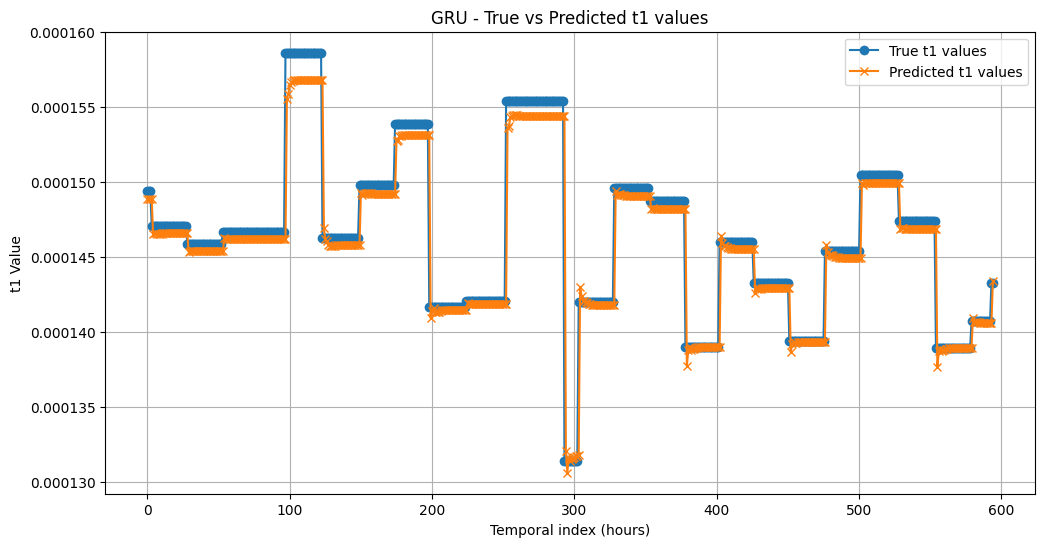

In [33]:
## Plot prediction
from random import randint
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = y_pred.cpu().numpy()
    y_true = y_test.cpu().numpy()


plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(y_true), label=f'True {metric} values', marker='o')
plt.plot(scaler.inverse_transform(y_pred), label=f'Predicted {metric} values', marker='x')
plt.title(f'GRU - True vs Predicted {metric} values')
plt.xlabel('Temporal index (hours)')
plt.ylabel(f'{metric} Value')
plt.legend()
plt.savefig("hourly_prediction_t1_fez_Gru.png")
plt.grid()

## Automatisation loop for benchmarking

In [35]:
'''
Running the benchmark over :
    - each backends
    - each metrics
    - diferents time lags
'''
benchmark = []
cols = df.columns[4:]
steps = [2, 10, 24]
simulation = []

criterion = nn.MSELoss()

for backend in [df_fez, df_torino, df_marrakesh]:
    for metric in cols:
        for step in steps:
            ## Datasets
            (X_train, y_train, X_val, y_val, X_test, y_test, scaler) = train_val_test_process_for_train(backend[[metric]], steps=step)

            n_features = X_train.shape[2]
            batch_size = 64
            
            train_dataset = TensorDataset(X_train, y_train)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            
            test_dataset = TensorDataset(X_test, y_test)
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
            
            val_dataset = TensorDataset(X_val, y_val)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

            ## Models
            models = {
                "Linear": LinearRegressionModel(
                    input_dim=X_train.shape[1]*X_train.shape[2],
                    output_dim=y_train.shape[1]
                ).to(device),

                "LSTM": LSTMModel(
                    input_dim=X_train.shape[2],
                    hidden_dim=10,
                    layer_dim=1,
                    output_dim=y_train.shape[1],
                    dropout_prob=dropout_prob
                ).to(device),

                "GRU": GRUModel(
                    input_dim=X_train.shape[2],
                    hidden_dim=10,
                    layer_dim=1,
                    output_dim=y_train.shape[1],
                    dropout_prob=dropout_prob
                ).to(device)
            }
            
            for model_name, model in models.items():
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
                training = Optimisation(model, criterion, optimizer)
                training.train(train_loader, val_loader, batch_size=batch_size, n_epochs=100, n_features=n_features, show_print=False)
    
                model.eval()
                with torch.no_grad():
                    y_pred = model(X_test.to(device))
                    y_pred = y_pred.cpu().numpy()
                    y_true = y_test.cpu().numpy()
                
                mae = mean_absolute_error(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                r2 = r2_score(y_true, y_pred)
                n = len(y_true) # On a len(y_true) prédiction et a chaque fois 1 seule valeurs de prédite
                k = step # Mon nombre de features 
                adj_r2 = 1 - ((1-r2)*(n-1))/(n-k-1) ## Formule du Adjusted-R-Squared
                benchmark.append({
                    "model": model_name,
                    'backend': backend['backend'].unique()[0],
                    "metric": metric,
                    "steps": step,
                    "mae": mae,
                    "rmse": rmse,
                    "r2" : r2,
                    "adjusted_r2": adj_r2    
                })

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Early stopping at epoch 84, train_loss = 0.0708	 Validation loss: 0.1381


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Early stopping at epoch 79, train_loss = 0.0912	 Validation loss: 0.1372


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Early stopping at epoch 61, train_loss = 0.3568	 Validation loss: 4.4751


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Early stopping at epoch 92, train_loss = 0.3642	 Validation loss: 3.3799
Early stopping at epoch 66, train_loss = 0.3583	 Validation loss: 55.5914


KeyboardInterrupt: 

In [ ]:
benchmark_df = pd.DataFrame(benchmark)
benchmark_df.to_csv("benchmark_results.csv", index=False)

# Daily

## Data-transformation

Aggregate hourly data into daily data by taking the median across all hourly measurements of each day, for each backend independently.  
Median is preferred over mean to limit the impact of outliers.

In [34]:
df_fez['day'] = df_fez['calibration_time'].dt.date
df_torino['day'] = df_torino['calibration_time'].dt.date
df_marrakesh['day'] = df_marrakesh['calibration_time'].dt.date

metrics = ['t1','t2','readout_error','prob_meas0_prep1','prob_meas1_prep0',
           'single_gates','cz_error','rzz_error']

df_torino_day = df_torino.groupby(['day'])[metrics].median().reset_index()
df_fez_day = df_fez.groupby(['day'])[metrics].median().reset_index()
df_marrakesh_day = df_marrakesh.groupby(['day'])[metrics].median().reset_index()

## Training

In [43]:
from torch.utils.data import TensorDataset, DataLoader

n_steps = 10
backend = df_fez_day
banckend_name = 'fez'
metric = 't1'

(X_train, y_train, X_val, y_val, X_test, y_test, scaler) = train_val_test_process_for_train(backend[[metric]], steps=n_steps)

n_features = X_train.shape[2]
batch_size = 5

X_train = X_train.to(device)
y_train = y_train.to(device)
X_val   = X_val.to(device)
y_val   = y_val.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [44]:
'''
Training model over our daily dataset to compare performance with the hourly one
'''
import numpy as np

## Main loop to train model
hidden_dim = 20
layer_dim =1
dropout_prob = 0.2

model = LSTMModel(input_dim = X_train.shape[2], hidden_dim = hidden_dim, layer_dim =layer_dim, output_dim = y_train.shape[1], dropout_prob=dropout_prob).to(device)
#model = LinearRegressionModel(input_dim=X_train.shape[1]*X_train.shape[2], output_dim=y_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training = Optimisation(model, criterion, optimizer)
training.train(train_loader, val_loader, batch_size=batch_size, n_epochs=1000, n_features=n_features)

model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = y_pred.cpu().numpy()
    y_true = y_test.cpu().numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
n = len(y_true) 
k = n_steps 
adj_r2 = 1 - ((1-r2)*(n-1))/(n-k-1)

print(f"R2: {r2:.6f}")
print(f"Adjusted R-Squared: {adj_r2} ")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1/1000, Loss: 1.0344
[1/1000] Training loss: 1.0344	 Validation loss: 1.6360
Epoch 2/1000, Loss: 1.0263
[2/1000] Training loss: 1.0263	 Validation loss: 1.6389
Epoch 3/1000, Loss: 1.0214
[3/1000] Training loss: 1.0214	 Validation loss: 1.6407
Epoch 4/1000, Loss: 1.0171
[4/1000] Training loss: 1.0171	 Validation loss: 1.6422
Epoch 5/1000, Loss: 1.0132
[5/1000] Training loss: 1.0132	 Validation loss: 1.6435
Epoch 6/1000, Loss: 1.0096
[6/1000] Training loss: 1.0096	 Validation loss: 1.6447
Epoch 7/1000, Loss: 1.0061
[7/1000] Training loss: 1.0061	 Validation loss: 1.6458
Epoch 8/1000, Loss: 1.0027
[8/1000] Training loss: 1.0027	 Validation loss: 1.6466
Epoch 9/1000, Loss: 0.9994
[9/1000] Training loss: 0.9994	 Validation loss: 1.6473
Epoch 10/1000, Loss: 0.9960
[10/1000] Training loss: 0.9960	 Validation loss: 1.6476
Epoch 11/1000, Loss: 0.9926
Early stopping at epoch 11, train_loss = 0.9926	 Validation loss: 1.6475
R2: -0.580769
Adjusted R-Squared: -3.7423068284988403 
MAE: 0.56500

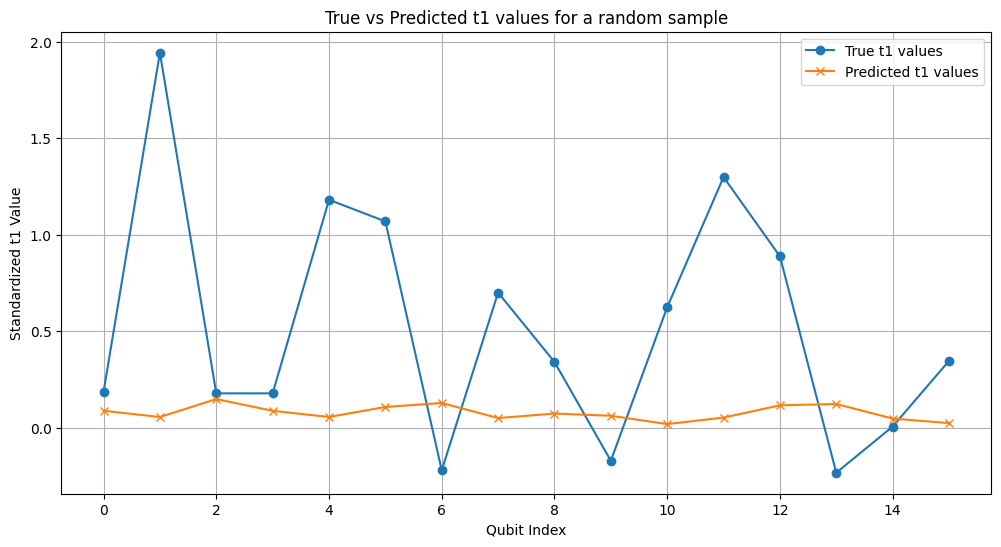

In [45]:
## Plot prediction
from random import randint
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = y_pred.cpu().numpy()
    y_true = y_test.cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(y_true, label=f'True {metric} values', marker='o')
plt.plot(y_pred, label=f'Predicted {metric} values', marker='x')
plt.title(f'True vs Predicted {metric} values for a random sample')
plt.xlabel('Qubit Index')
plt.ylabel(f'Standardized {metric} Value')
plt.legend()
plt.grid()
plt.show()

## Diferent approach

We try using the past values of other features as exogenous variables to predict the target, assuming cross-feature temporal dependencies may improve forecasting performance.

In [46]:
from torch.utils.data import DataLoader

## Parameters
steps = 5
feature_cols = ['t1','t2','cz_error','rzz_error','single_gates']
target_col_name = 't1'
dataframe = df_fez_day
batch_size = 3

target_col = feature_cols.index(target_col_name)
dataframe = dataframe[feature_cols]

## Split and scaling
train, val, test = split_data(dataframe)
train_scaled, scaler = prepare_data(train)
val_scaled = scaler.transform(val) 
test_scaled = scaler.transform(test)

## TimeSeries dataset
train_dataset = TimeSeriesDataset(train_scaled, steps, target_col)
val_dataset = TimeSeriesDataset(val_scaled, steps, target_col)
test_dataset = TimeSeriesDataset(test_scaled, steps, target_col)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [47]:
### from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## Main loop to train model
hidden_dim = 10
layer_dim =2
dropout_prob = 0.2

model = GRUModel(input_dim = len(feature_cols), hidden_dim = hidden_dim, layer_dim =layer_dim, output_dim = 1, dropout_prob=dropout_prob).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training = Optimisation(model, criterion, optimizer)
training.train(train_loader, val_loader, batch_size=batch_size, n_epochs=1000, n_features=n_features)

## Evaluation of the model
y_pred_list = []
y_true_list = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        pred = model(x_batch)              
        y_pred_list.append(pred.cpu())      
        y_true_list.append(y_batch.cpu()) 

# Concaténer tous les batches
y_pred = torch.cat(y_pred_list, dim=0).numpy() 
y_true = torch.cat(y_true_list, dim=0).numpy() 

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
n = len(y_true) # On a len(y_true) prédiction et a chaque fois 1 seule valeurs de prédite
k = n_steps # Mon nombre de features 
adj_r2 = 1 - ((1-r2)*(n-1))/(n-k-1) ## Formule du Adjusted-R-Squared

print(f"R2: {r2:.6f}")
print(f"Adjusted R-Squared: {adj_r2} ")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

results.append({
    "model": "GRU",
    "hidden_dim" : hidden_dim,
    "layer_dim" : layer_dim,
    "dropout_prob" : dropout_prob,
    'backend': banckend_name,
    "metric": metric,
    "steps": n_steps,
    "mae": mae,
    "rmse": rmse,
    "r2" : r2,
    "adjusted_r2": adj_r2    
})

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([3])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/1000, Loss: 1.0457
[1/1000] Training loss: 1.0457	 Validation loss: 2.0368
Epoch 2/1000, Loss: 1.0294
[2/1000] Training loss: 1.0294	 Validation loss: 1.9952
Epoch 3/1000, Loss: 1.0119
[3/1000] Training loss: 1.0119	 Validation loss: 1.9591
Epoch 4/1000, Loss: 1.0080
[4/1000] Training loss: 1.0080	 Validation loss: 1.9225
Epoch 5/1000, Loss: 0.9943
[5/1000] Training loss: 0.9943	 Validation loss: 1.8989
Epoch 6/1000, Loss: 0.9678
[6/1000] Training loss: 0.9678	 Validation loss: 1.8745
Epoch 7/1000, Loss: 0.9745
[7/1000] Training loss: 0.9745	 Validation loss: 1.8602
Epoch 8/1000, Loss: 0.9562
[8/1000] Training loss: 0.9562	 Validation loss: 1.8501
Epoch 9/1000, Loss: 0.9713
[9/1000] Training loss: 0.9713	 Validation loss: 1.8491
Epoch 10/1000, Loss: 0.9404
[10/1000] Training loss: 0.9404	 Validation loss: 1.8507
Epoch 11/1000, Loss: 0.9357
Epoch 12/1000, Loss: 0.9142
Epoch 13/1000, Loss: 0.8913
Epoch 14/1000, Loss: 0.8974
Epoch 15/1000, Loss: 0.8978
Epoch 16/1000, Loss: 0.9295


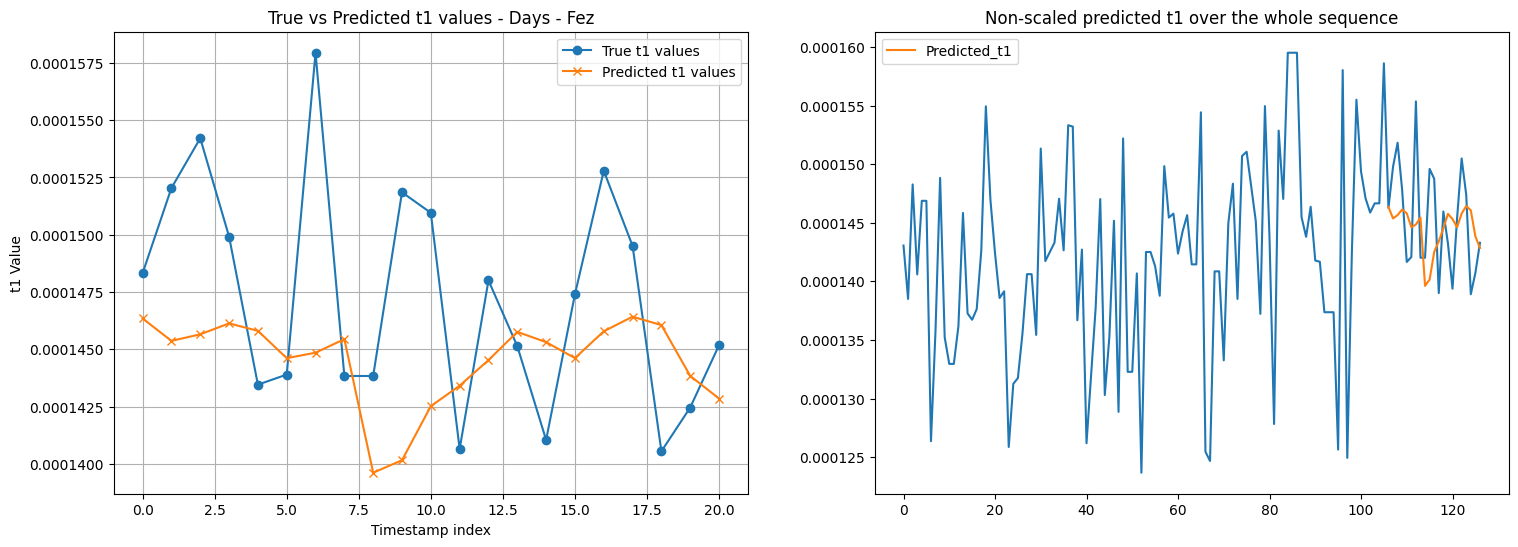

In [48]:
## Plot prediction
from random import randint
import matplotlib.pyplot as plt

y_pred_list = []
y_true_list = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        pred = model(x_batch) 
        y_pred_list.append(pred.cpu())
        y_true_list.append(y_batch.cpu())

y_pred = torch.cat(y_pred_list, dim=0).numpy() 
y_true = torch.cat(y_true_list, dim=0).numpy()
scaler = StandardScaler() ;_ = scaler.fit_transform(dataframe[[target_col_name]]) ;y_pred = scaler.inverse_transform(y_pred) ## InverseTransform prediction

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(scaler.inverse_transform(y_true.reshape(-1, 1)), label=f'True {metric} values', marker='o')
axes[0].plot(y_pred, label=f'Predicted {metric} values', marker='x')
axes[0].set_title(f'True vs Predicted {metric} values - Days - Fez')
axes[0].set_xlabel('Timestamp index')
axes[0].set_ylabel(f'{metric} Value')
axes[0].legend()
axes[0].grid()

## Show real pred

start = len(dataframe) - len(test_dataset); end = len(dataframe); x_pred = np.arange(start, end)
axes[1].plot(dataframe[target_col_name])
axes[1].plot(x_pred, y_pred, label="Predicted_t1")
axes[1].legend()
axes[1].set_title(f'Non-scaled predicted {metric} over the whole sequence')
plt.savefig('predicted_T1_fez_days.png')
plt.show()

## Daily Benchmark

In [ ]:
benchmark = []
cols = df_fez_day.columns[1:]
steps = [2, 10, 24]
simulation = []

criterion = nn.MSELoss()

for backend, name in zip([df_fez_day, df_torino_day, df_marrakesh_day], ['fez', 'torino', 'marrakesh']):
    for metric in cols:
        for step in steps:
            ## Datasets
            (X_train, y_train, X_val, y_val, X_test, y_test, scaler) = train_val_test_process_for_train(backend[[metric]], steps=step)

            n_features = X_train.shape[2]
            batch_size = 5

            X_train = X_train.to(device)
            y_train = y_train.to(device)
            X_val   = X_val.to(device)
            y_val   = y_val.to(device)
            X_test  = X_test.to(device)
            y_test  = y_test.to(device)
            
            train_dataset = TensorDataset(X_train, y_train)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            
            test_dataset = TensorDataset(X_test, y_test)
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
            
            val_dataset = TensorDataset(X_val, y_val)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

            ## Models
            models = {
                "Linear": LinearRegressionModel(
                    input_dim=X_train.shape[1]*X_train.shape[2],
                    output_dim=y_train.shape[1]
                ).to(device),

                "LSTM": LSTMModel(
                    input_dim=X_train.shape[2],
                    hidden_dim=10,
                    layer_dim=1,
                    output_dim=y_train.shape[1],
                    dropout_prob=dropout_prob
                ).to(device),

                "GRU": GRUModel(
                    input_dim=X_train.shape[2],
                    hidden_dim=10,
                    layer_dim=1,
                    output_dim=y_train.shape[1],
                    dropout_prob=dropout_prob
                ).to(device)
            }
            
            for model_name, model in models.items():
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
                training = Optimisation(model, criterion, optimizer)
                training.train(train_loader, val_loader, batch_size=batch_size, n_epochs=100, n_features=n_features, show_print=False)
    
                model.eval()
                with torch.no_grad():
                    y_pred = model(X_test.to(device))
                    y_pred = y_pred.cpu().numpy()
                    y_true = y_test.cpu().numpy()
                
                mae = mean_absolute_error(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                r2 = r2_score(y_true, y_pred)
                n = len(y_true) # On a len(y_true) prédiction et a chaque fois 1 seule valeurs de prédite
                k = step # Mon nombre de features 
                adj_r2 = 1 - ((1-r2)*(n-1))/(n-k-1) ## Formule du Adjusted-R-Squared

                benchmark.append({
                    "model": model_name,
                    'backend': name,
                    "metric": metric,
                    "steps": step,
                    "mae": mae,
                    "rmse": rmse,
                    "r2" : r2,
                    "adjusted_r2": adj_r2    
                })

In [45]:
benchmark_daily_df = pd.DataFrame(benchmark)
benchmark_daily_df.to_csv("day_benchmark_results.csv", index=False)

NameError: name 'benchmark' is not defined

# Sarimax 

In [49]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.7 MB/s eta 0:00:00 0:00:01


## Training

With this plot we notice several things :   
- the series is obviously **stationnary**
- we notice the more important lags are **t-1, t-2 and t-3**

In [50]:
from pmdarima.arima import auto_arima

def sarimax_train(df, feature, seasonal=True, stationary=True, p=3, q=3, s=0, standardize=None, show_print=False):
    '''
    Train, and compute metrics for sarimax model with given prior
    Input: 
        - df: dataframe with calibration data
        - feature: target feature we want to forecast
        - seasonal: True if the series show seasonality (default to True)
        - stationnary: True if the series is stationary (default to True)
        - p: number of points in the past that we want to use to predict t
        - q: number of past errors to use to correct the new prediction (Moving Average)
        - s: type of saisonality
        - show_print: to print the metrics and plot the prediction
    Output:
        - model: trained sarimax model
        - SARIMAX_model: set of parameter ans settings of our model
        - mae: average of the absolute error on the test set
        - rmse: average of the square root of the square error
        - r2: explained variance by our model
        - r2_adj: trade-off between model complexity and explained variance of our model
    '''
    y = df[feature]
    scaler = StandardScaler()
    
    split = int(len(y) * 0.8)
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    if standardize:
        y_train = pd.DataFrame(
            scaler.fit_transform(y_train.values.reshape(-1, 1)),
            index=y_train.index,
            columns=[feature]
        )
        
        y_test = pd.DataFrame(
            scaler.transform(y_test.values.reshape(-1, 1)),
            index=y_test.index,
            columns=[feature]
        )
    
    SARIMAX_model = auto_arima(y_train,start_p=1, start_q=1,test='adf',s = s, max_p=p, max_q=q,start_P=0, stationary=stationary,
                               seasonal=seasonal,trace=True,error_action='ignore',suppress_warnings=True,stepwise=True)
    
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    
    model = SARIMAX(
        y_train,
        order=SARIMAX_model.order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    sarimax_fit = model.fit(disp=False)
    if show_print:
        print(sarimax_fit.summary())
    
    y_pred = sarimax_fit.predict(start=y_test.index[0],
                                 end=y_test.index[-1])
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    k = len(sarimax_fit.params)
    n = len(y_test)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    if show_print:
        print(f"MAE: {mae:.6f}")
        print(f"RMSE: {rmse:.6f}")
        print(f"R2: {r2:.6f}")
        print(f"Adjusted-R2: {r2_adj:.6f}")

    if show_print:
        plt.figure(figsize=(12,5))
        plt.plot(y_train.index, y_train, label="Train")
        plt.plot(y_test.index, y_test, label="Test")
        plt.plot(y_pred.index, y_pred, label="Prediction SARIMAX", color='darkgreen')
        plt.legend()
        plt.savefig("prediction_sarimax.png")
        plt.show()

    return model, SARIMAX_model, mae, rmse, r2, r2_adj

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2063.761, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2065.011, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2068.106, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2062.658, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1501.399, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-2067.459, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-2059.610, Time=0.22 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.776 seconds
                               SARIMAX Results                                
Dep. Variable:                     t1   No. Observations:                  101
Model:               SARIMAX(1, 0, 0)   Log Likelihood                1000.784
Date:                Fri, 27 Mar 2026   AIC                          -1997.567
Time:                        16:18

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


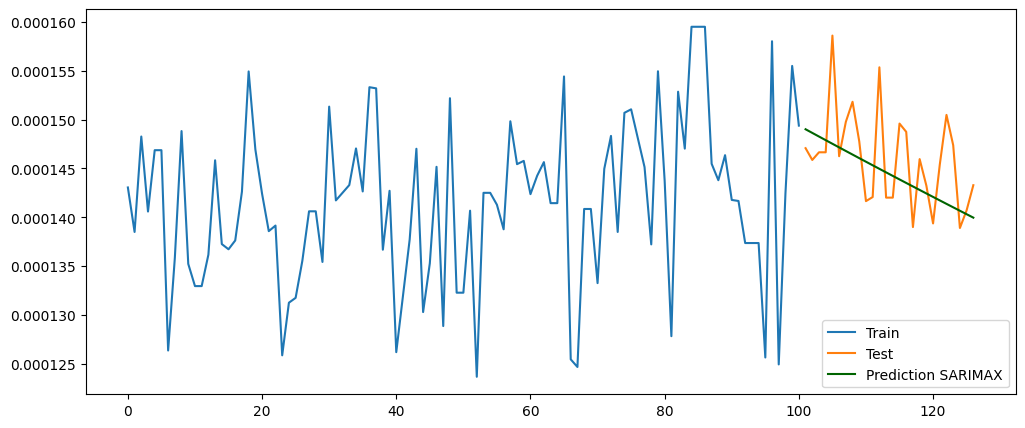

In [51]:
## p -> is the number of points in the past that we want to use to predict t
## d -> value used to make the series stationary (here rather useless), so d=0
## q -> number of past errors to use to correct the new prediction (Moving Average)
## s -> type of saisonality
## more important lag at t-1, t-2 and t-3
## Using SARIMAX with no seasonality and no exog variable is equivalent to using ARIMA

model, SARIMAX_model, mae, rmse, r2, r2_adj = sarimax_train(df_fez_day, 't1', stationary=True, standardize=None, seasonal=False, show_print=True)

The series seemed more or less stationary, however, due to a lack of data, it now appears to be stationary in parts.

### T1 (avec exog)
SARIMAX allow us to use what we call exogenous variable. Those can be really usefull to add information to a moment we want to predict. 

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2063.761, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2065.011, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2068.106, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2062.658, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1501.399, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-2067.459, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-2059.610, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.660 seconds


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                     t1   No. Observations:                  101
Model:               SARIMAX(1, 0, 0)   Log Likelihood                1060.759
Date:                Fri, 27 Mar 2026   AIC                          -2103.518
Time:                        16:18:34   BIC                          -2080.072
Sample:                             0   HQIC                         -2094.029
                                - 101                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
t2                   1.1207   5.62e-05      2e+04      0.000       1.121       1.121
readout_error        0.0022      0.005      0.476      0.634      -0.007       0.011
prob_meas0_prep1     0.0012 

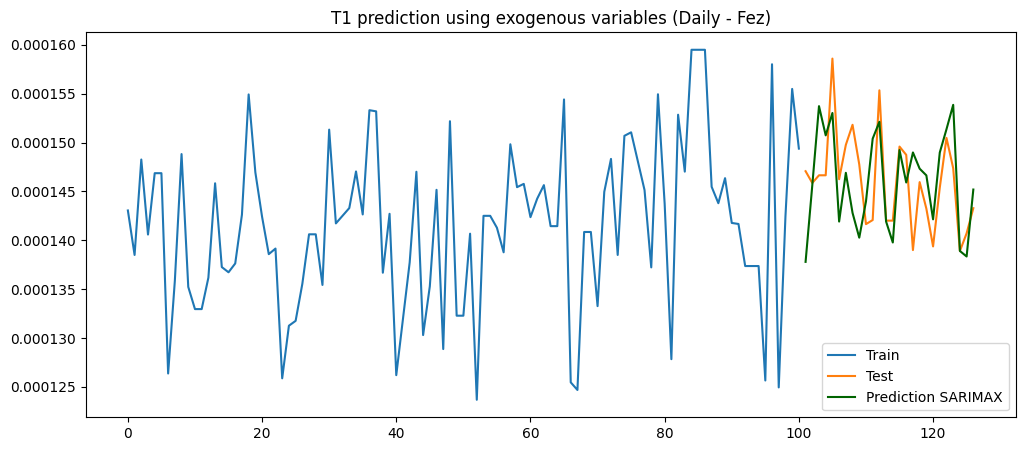

In [52]:
from pmdarima.arima import auto_arima
exog_vars = ["t2","readout_error","prob_meas0_prep1","prob_meas1_prep0","single_gates","cz_error","rzz_error",]
exog = df_fez_day[exog_vars]
y = df_fez_day["t1"]

split = int(len(y) * 0.8)
y_train, y_test = y.iloc[:split], y.iloc[split:]
exog_train, exog_test = exog.iloc[:split], exog.iloc[split:]

SARIMAX_model = auto_arima(y_train,exog=exog_train, start_p=1, start_q=1,test='adf',max_p=3, max_q=3,start_P=0, 
                           seasonal=True,trace=True,stationnary=True,error_action='ignore',suppress_warnings=True,stepwise=True)

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    order=SARIMAX_model.order,
    enforce_stationarity=False,
    enforce_invertibility=False,
    exog=exog_train
)

sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

y_pred = sarimax_fit.predict(start=y_test.index[0],
                             end=y_test.index[-1],
                             exog=exog_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
k = len(sarimax_fit.params)
n = len(y_test)
r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2: {r2:.6f}")
print(f"Adjusted-R2: {r2_adj:.6f}")


plt.figure(figsize=(12,5))
plt.title('T1 prediction using exogenous variables (Daily - Fez)')
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test")
plt.plot(y_pred.index, y_pred, label="Prediction SARIMAX", color='darkgreen')
plt.legend()
plt.savefig('t1_fez_exog.png')
plt.show()

### Signal decomposition

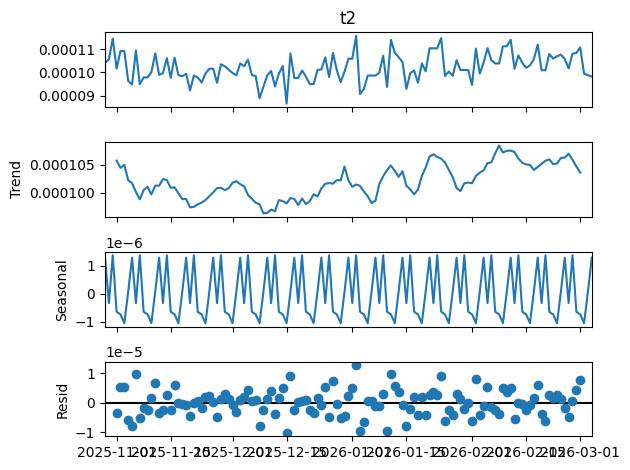

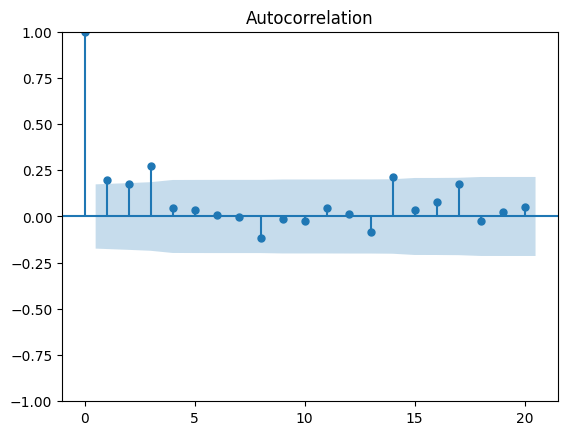

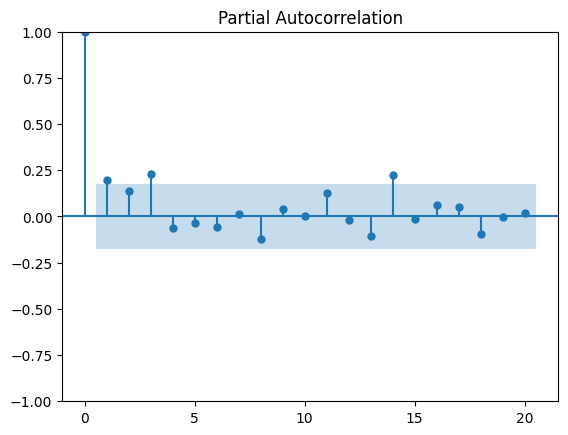

In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def decompose(df, feature, period=7):
    df_copy = df.copy()
    
    df_copy = df_copy.set_index("day")
    y = df_copy[feature]
    
    result = seasonal_decompose(df_copy['t2'], period=period) ## Will try to give you a pattern in any case
    
    result.plot()
    plt.show()
    
    plot_acf(y, lags=20)
    plt.show()
    
    plot_pacf(y, lags=20)
    plt.show()

decompose(df_fez_day, 't1')

## Test - Plot of white noise to compare with my calibration evolution of T1

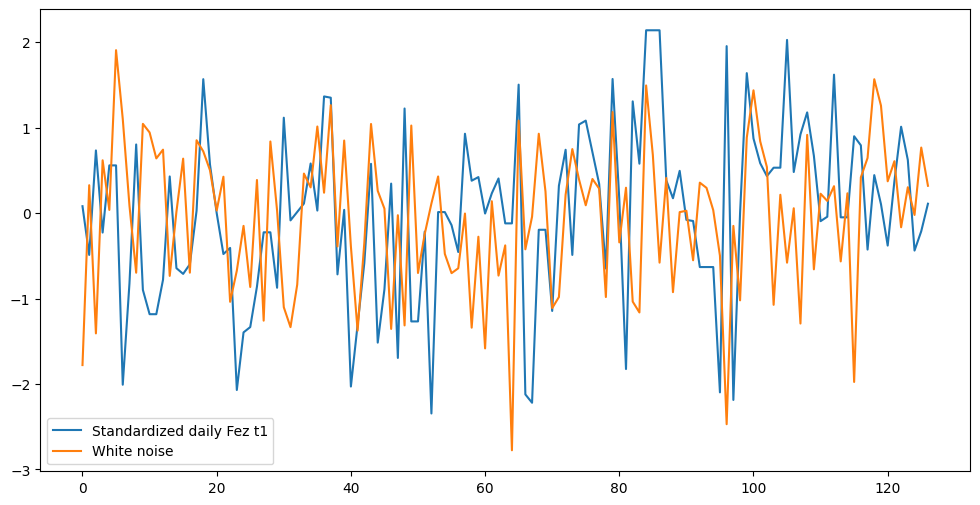

In [56]:
plt.figure(figsize=(12,6))
scaler = StandardScaler()
df_plot = scaler.fit_transform(df_fez_day[['t1']])
n = len(df_fez_day)
mu, sigma = 0, 1 
white_noise = np.random.normal(mu, sigma, n)
plt.plot(df_plot, label='Standardized daily Fez t1')
plt.plot(white_noise, label='White noise')
plt.legend()
plt.savefig('random.png')
plt.show()

## Readout error VS Random Walk

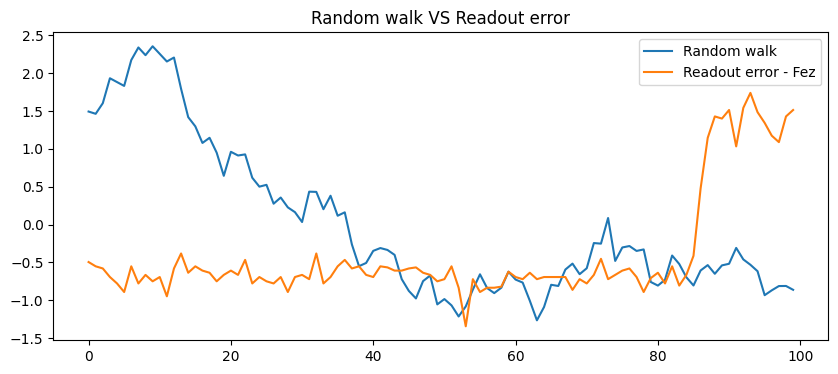

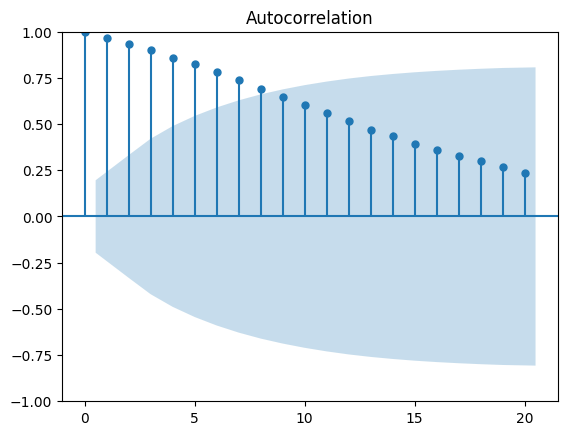

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
n = 100
epsilon = np.random.normal(0, 1, n)
y = np.cumsum(epsilon)  # marche aléatoire
y = StandardScaler().fit_transform(y.reshape(-1, 1))
df_readout_plot = StandardScaler().fit_transform(df_fez_day[['readout_error']])
plt.figure(figsize=(10,4))
plt.plot(y, label='Random walk')
plt.plot(df_readout_plot[:100], label='Readout error - Fez')
plt.title("Random walk VS Readout error")
plt.legend()
plt.show()

plot_acf(y, lags=20)
plt.show()

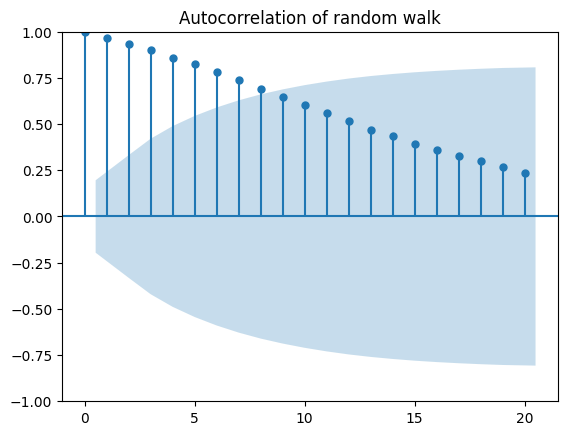

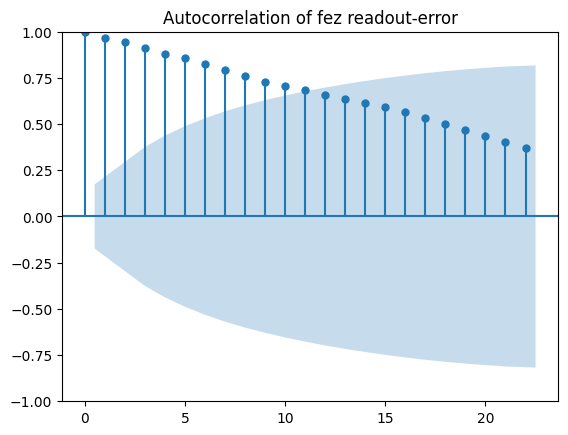

In [58]:
plot_acf(y, lags=20)
plt.title('Autocorrelation of random walk')
plt.show()

plot_acf(df_fez_day[['readout_error']])
plt.title('Autocorrelation of fez readout-error')
plt.show()

## Hourly Sarimax

Using SARIMAX on our hourly dataset

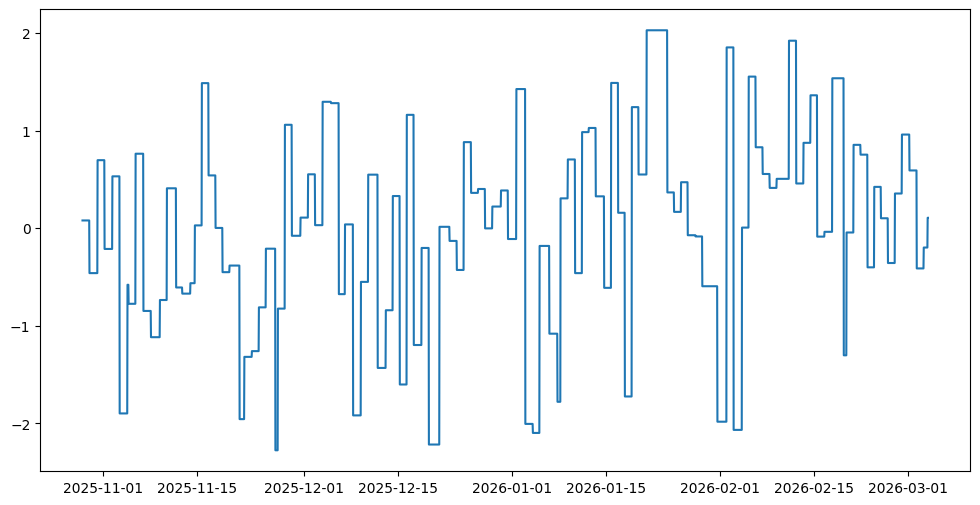

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3025 entries, 2025-10-29 00:00:00 to 2026-03-04 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t1      3025 non-null   float64
dtypes: float64(1)
memory usage: 47.3 KB


In [59]:
df_fez_rr = df_fez.set_index('calibration_time')
sub_df = df_fez_rr[['t1']]

scaler = StandardScaler()
scaled_sub_df = sub_df.copy()
scaled_sub_df['t1'] = scaler.fit_transform(sub_df)

plt.figure(figsize=(12,6))
plt.plot(scaled_sub_df)
plt.show()

sub_df.info()

Stationnary


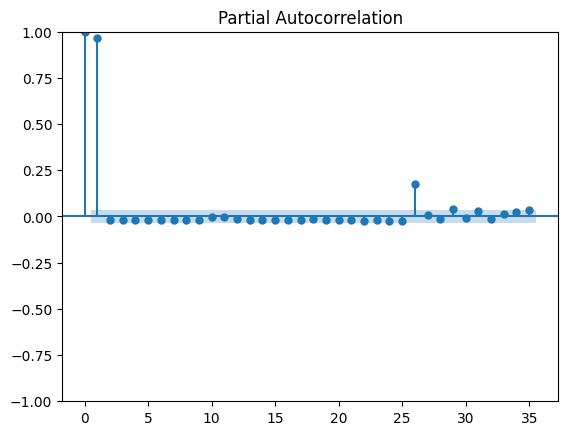

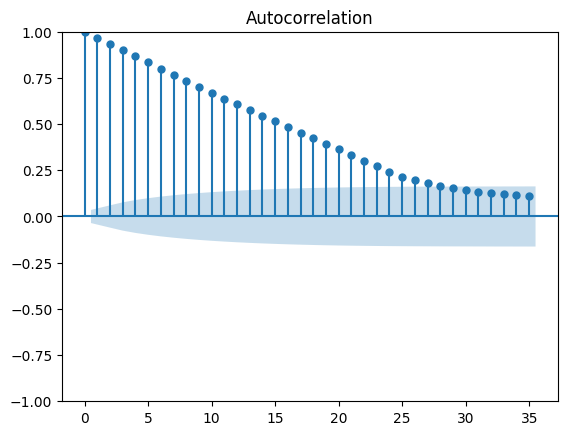

In [60]:
## Test Dickey-Fuller
from statsmodels.tsa.stattools import adfuller

rsl = adfuller(scaled_sub_df)
if rsl[1] <= 0.05:
    print('Stationnary')

plot_pacf(scaled_sub_df)
plot_acf(scaled_sub_df)
plt.show()

Here, the auto-correlation plot show us only the $t-1$ value have an importance for $t$, however for the auto correlation plot we see that many time lages can be usefull to explain $t$.

In [61]:
split = int(len(scaled_sub_df) * 0.8)
train_df = scaled_sub_df[:split]
test_df = scaled_sub_df[split:]

In [62]:
## 24 for 24 hours a day
stepwise_fit = auto_arima(train_df, seasonal=True, m=5, max_p = 5, max_q = 5, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=561.072, Time=0.78 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=549.072, Time=0.17 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=553.072, Time=1.44 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=553.072, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=547.075, Time=0.14 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=551.072, Time=0.43 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=551.072, Time=0.51 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=553.072, Time=0.44 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=551.072, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=551.072, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=553.072, Time=0.27 sec

Best model:  ARIMA(0,1,0)(0,0,0)[5]          
Total fit time: 5.318 seconds


In [63]:
print(stepwise_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2420
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -272.538
Date:                Fri, 27 Mar 2026   AIC                            547.075
Time:                        16:20:45   BIC                            552.866
Sample:                    10-29-2025   HQIC                           549.181
                         - 02-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0733      0.000    224.408      0.000       0.073       0.074
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            665767.32
Prob(Q):                              1.00   Pr

In [64]:
model = SARIMAX(train_df, order=stepwise_fit.order, seasonal_order = stepwise_fit.seasonal_order)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [65]:
fitted_model = model.fit(disp = False)

In [66]:
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                     t1   No. Observations:                 2420
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -272.538
Date:                Fri, 27 Mar 2026   AIC                            547.075
Time:                        16:20:45   BIC                            552.866
Sample:                    10-29-2025   HQIC                           549.181
                         - 02-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0733      0.000    224.408      0.000       0.073       0.074
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            665767.32
Prob(Q):                              1.00   Pr

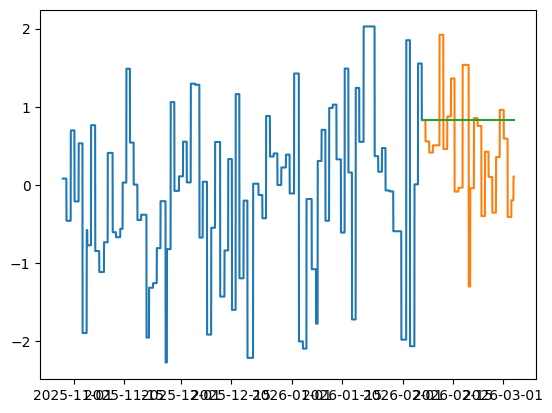

In [67]:
pred = fitted_model.predict(start = test_df.index[0], end = test_df.index[-1])
plt.plot(train_df)
plt.plot(test_df)
plt.plot(pred)

## Benchmark

In [146]:
benchmark = []
cols = df_fez_day.columns[1:]
steps = [2, 10, 24]
simulation = []

criterion = nn.MSELoss()

for backend, name in zip([df_fez_day, df_torino_day, df_marrakesh_day], ['fez', 'torino', 'marrakesh']):
    for metric in cols:
        model, SARIMAX_model, mae, rmse, r2, r2_adj = sarimax_train(backend, metric, stationary=True, standardize=True, seasonal=False, show_print=False)
        benchmark.append({
            'backend': name,
            "metric": metric,
            "order": SARIMAX_model.order,
            "mae": mae,
            "rmse": rmse,
            "r2" : r2,
            "adjusted_r2": adj_r2    
        })

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=289.994, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=290.626, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=290.087, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=290.524, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=288.626, Time=0.01 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.135 seconds
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=291.722, Time=0.16 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=290.626, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=291.263, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=291.563, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=288.626, Time=0.01 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.228 seconds
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=57.192, Time=0.08 sec
 AR

In [147]:
benchmark

[{'backend': 'fez',
  'metric': 't1',
  'order': (0, 0, 0),
  'mae': 0.6093880159001784,
  'rmse': np.float64(0.7829620821521419),
  'r2': -0.8834030779308482,
  'adjusted_r2': -2.4020018577575684},
 {'backend': 'fez',
  'metric': 't2',
  'order': (0, 0, 0),
  'mae': 0.8417925880456512,
  'rmse': np.float64(1.046935878803864),
  'r2': -0.9671696474987888,
  'adjusted_r2': -2.4020018577575684},
 {'backend': 'fez',
  'metric': 'readout_error',
  'order': (1, 0, 0),
  'mae': 1.3418958138812167,
  'rmse': np.float64(1.4055448398704722),
  'r2': -23.709743112400588,
  'adjusted_r2': -2.4020018577575684},
 {'backend': 'fez',
  'metric': 'prob_meas0_prep1',
  'order': (1, 0, 0),
  'mae': 0.6894660965791574,
  'rmse': np.float64(0.7623916742229173),
  'r2': -4.44146667960232,
  'adjusted_r2': -2.4020018577575684},
 {'backend': 'fez',
  'metric': 'prob_meas1_prep0',
  'order': (1, 0, 1),
  'mae': 0.46906522298265835,
  'rmse': np.float64(0.5398208181598679),
  'r2': -0.5885439860487744,
  'adju

In [148]:
benchmark_df = pd.DataFrame(benchmark)
benchmark_df.to_csv("benchmark_sarimax.csv", index=False)

In [149]:
benchmark_df

,backend,metric,order,mae,rmse,r2,adjusted_r2
0,fez,t1,"(0, 0, 0)",0.609388,0.782962,-0.883403,-2.402002
1,fez,t2,"(0, 0, 0)",0.841793,1.046936,-0.967170,-2.402002
2,fez,readout_error,"(1, 0, 0)",1.341896,1.405545,-23.709743,-2.402002
3,fez,prob_meas0_prep1,"(1, 0, 0)",0.689466,0.762392,-4.441467,-2.402002
4,fez,prob_meas1_prep0,"(1, 0, 1)",0.469065,0.539821,-0.588544,-2.402002
5,fez,single_gates,"(0, 0, 0)",0.754184,1.007591,-0.195816,-2.402002
6,fez,cz_error,"(1, 0, 0)",0.712510,0.911862,-0.119496,-2.402002
7,fez,rzz_error,"(0, 0, 0)",0.550580,1.008988,-0.002270,-2.402002
8,torino,t1,"(1, 0, 0)",1.170030,1.295147,-1.838147,-2.402002
9,torino,t2,"(0, 0, 1)",1.195558,1.525786,-1.172593,-2.402002
